In [2]:
!pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 4.2 MB/s eta 0:00:00


In [3]:
import numpy as np
import torch
import copy
import random
from functools import reduce
from torch.optim import Optimizer
import kan.LBFGS as LBFGS


SEED = 0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Make CUDA deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def fit(
    model, dataset, opt="LBFGS", steps=100, log=1,
    lamb=0., lamb_l1=1., lamb_entropy=2., lamb_coef=0., lamb_coefdiff=0.,
    update_grid=True, grid_update_num=10, loss_fn=None, lr=1.,
    start_grid_update_step=-1, stop_grid_update_step=50, batch=-1, metrics=None,
    in_vars=None, out_vars=None, beta=3, singularity_avoiding=False, y_th=1000.,
    reg_metric='edge_forward_spline_n', display_metrics=None, k=1,

    # ---- NEW: integrated rollout loss ------------------------------------------
    rollout_weight=0.0,          # set >0 to enable integration loss
    rollout_horizon=None,        # int number of steps (<= T-1). None => use full T-1
    traj_batch=-1,               # how many trajectories per step (-1 => all)
    dynamics_fn=None,            # optional: f(state)->dstate/dt. defaults to model.forward(state)
    integrator="rk4",            # "euler" or "rk4"
):
    """
    Adds an optional differentiable integration loss:
        if dataset contains 'train_traj' and 'train_t' and rollout_weight>0,
        we integrate ds/dt = f_theta(s) and match predicted states to train_traj.

    Notes:
    - This assumes the model maps STATE -> DERIVATIVE for the rollout term.
      If your model needs feature transforms (Theta, normalization, etc.),
      pass a custom dynamics_fn(state) that does that and returns dstate/dt.
    """

    assert k >= 1, "k must be >= 1"

    # -------------------------------------------------------------------------
    # Original k-step forward (kept for backward compatibility)
    # -------------------------------------------------------------------------
    def k_step_forward(inputs):
        state = inputs
        for _ in range(k):
            state = model.forward(state, singularity_avoiding=singularity_avoiding, y_th=y_th)
        return state

    # -------------------------------------------------------------------------
    # NEW: dynamics function for ODE rollout
    # -------------------------------------------------------------------------
    if dynamics_fn is None:
        def dynamics_fn(state):
            # default: treat model.forward(state) as f_theta(state)
            return model.forward(state, singularity_avoiding=singularity_avoiding, y_th=y_th)

    # Differentiable integrators (batch-safe)
    def euler_step(s, dt):
        return s + dt * dynamics_fn(s)

    def rk4_step(s, dt):
        k1 = dynamics_fn(s)
        k2 = dynamics_fn(s + 0.5 * dt * k1)
        k3 = dynamics_fn(s + 0.5 * dt * k2)
        k4 = dynamics_fn(s + dt * k3)
        return s + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    def integrate_states(s0, t):
        """
        s0: (B, state_dim)
        t:  (B, T) or (T,)
        returns: pred_traj (B, T, state_dim)
        """
        if t.dim() == 1:
            # broadcast to (B,T)
            t = t.unsqueeze(0).expand(s0.shape[0], -1)
        B, T = t.shape
        state = s0
        out = [state]

        H = T - 1 if rollout_horizon is None else min(rollout_horizon, T - 1)

        for i in range(H):
            dt = (t[:, i+1] - t[:, i]).unsqueeze(1)  # (B,1)
            if integrator.lower() == "euler":
                state = euler_step(state, dt)
            elif integrator.lower() == "rk4":
                state = rk4_step(state, dt)
            else:
                raise ValueError(f"Unknown integrator: {integrator}")
            out.append(state)

        # If horizon < T-1, we only return the integrated prefix
        pred = torch.stack(out, dim=1)  # (B, H+1, state_dim)
        return pred

    # -------------------------------------------------------------------------
    # Symbolics & activation saving logic (unchanged)
    # -------------------------------------------------------------------------
    if lamb > 0. and not model.save_act:
        print("setting lamb=0. If you want lamb>0, set model.save_act=True")
    old_save_act, old_symbolic_enabled = model.disable_symbolic_in_fit(lamb)

    # -------------------------------------------------------------------------
    # Loss fn
    # -------------------------------------------------------------------------
    if loss_fn is None:
        loss_fn = loss_fn_eval = lambda x, y: torch.mean((x - y) ** 2)
    else:
        loss_fn = loss_fn_eval = loss_fn

    # -------------------------------------------------------------------------
    # Grid update frequency
    # -------------------------------------------------------------------------
    grid_update_freq = max(1, int(stop_grid_update_step / grid_update_num))

    # -------------------------------------------------------------------------
    # Optimizer
    # -------------------------------------------------------------------------
    if opt == "Adam":
        optimizer = torch.optim.Adam(model.get_params(), lr=lr)
    else:
        optimizer = LBFGS(
            model.get_params(), lr=lr, history_size=10,
            line_search_fn="strong_wolfe",
            tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32
        )

    # -------------------------------------------------------------------------
    # Tracking
    # -------------------------------------------------------------------------
    results = dict(train_loss=[], test_loss=[], reg=[], rollout_train_loss=[], rollout_test_loss=[])
    if metrics is not None:
        for m in metrics:
            results[m.__name__] = []

    # -------------------------------------------------------------------------
    # Batching for derivative supervision (unchanged)
    # -------------------------------------------------------------------------
    n_train = dataset['train_input'].shape[0]
    n_test  = dataset['test_input'].shape[0]
    batch_size      = n_train if batch == -1 or batch > n_train else batch
    batch_size_test = n_test  if batch == -1 or batch > n_test  else batch

    # -------------------------------------------------------------------------
    # Batching for trajectories (new)
    # -------------------------------------------------------------------------
    has_train_traj = ('train_traj' in dataset) and ('train_t' in dataset)
    has_test_traj  = ('test_traj' in dataset) and ('test_t' in dataset)

    if has_train_traj:
        n_traj_train = dataset['train_traj'].shape[0]
        traj_batch_size = n_traj_train if traj_batch == -1 or traj_batch > n_traj_train else traj_batch
    else:
        n_traj_train = 0
        traj_batch_size = 0

    if has_test_traj:
        n_traj_test = dataset['test_traj'].shape[0]
        traj_batch_size_test = n_traj_test if traj_batch == -1 or traj_batch > n_traj_test else traj_batch
    else:
        n_traj_test = 0
        traj_batch_size_test = 0

    global train_loss, reg_, rollout_train_loss

    # -------------------------------------------------------------------------
    # Helper to compute rollout loss on a batch of trajectories
    # -------------------------------------------------------------------------
    def rollout_loss_on_batch(traj, t):
        """
        traj: (B, T, state_dim) true
        t:    (T,) or (B, T)
        """
        s0 = traj[:, 0, :]                  # (B, state_dim)
        pred = integrate_states(s0, t)      # (B, H+1, state_dim)
        true = traj[:, :pred.shape[1], :]   # align horizons
        return loss_fn(pred, true)

    # -------------------------------------------------------------------------
    # LBFGS closure (updated to include rollout term)
    # -------------------------------------------------------------------------
    def closure():
        global train_loss, reg_, rollout_train_loss
        optimizer.zero_grad()

        # --- derivative supervision (your current behavior)
        pred = k_step_forward(dataset['train_input'][train_id])
        train_loss = loss_fn(pred, dataset['train_label'][train_id])

        # --- integrated rollout loss (new)
        if rollout_weight > 0.0 and has_train_traj:
            traj = dataset['train_traj'][traj_id]
            tt   = dataset['train_t']
            rollout_train_loss = rollout_loss_on_batch(traj, tt)
        else:
            rollout_train_loss = torch.tensor(0.0, device=pred.device)

        # --- reg (unchanged)
        if model.save_act:
            if reg_metric == "edge_backward": model.attribute()
            if reg_metric == "node_backward": model.node_attribute()
            reg_ = model.get_reg(reg_metric, lamb_l1, lamb_entropy, lamb_coef, lamb_coefdiff)
        else:
            reg_ = torch.tensor(0., device=pred.device)

        obj = train_loss + rollout_weight * rollout_train_loss + lamb * reg_
        obj.backward()
        return obj

    # -------------------------------------------------------------------------
    # MAIN LOOP
    # -------------------------------------------------------------------------
    train_ptr = 0
    test_ptr = 0
    traj_ptr = 0
    traj_test_ptr = 0

    for step in range(steps):
        # --- derivative batches (unchanged)
        train_id = np.arange(train_ptr, train_ptr + batch_size) % n_train
        train_ptr = (train_ptr + batch_size) % n_train

        test_id = np.arange(test_ptr, test_ptr + batch_size_test) % n_test
        test_ptr = (test_ptr + batch_size_test) % n_test

        # --- trajectory batches (new)
        if has_train_traj and rollout_weight > 0.0:
            traj_id = np.arange(traj_ptr, traj_ptr + traj_batch_size) % n_traj_train
            traj_ptr = (traj_ptr + traj_batch_size) % n_traj_train

        if has_test_traj and rollout_weight > 0.0:
            traj_test_id = np.arange(traj_test_ptr, traj_test_ptr + traj_batch_size_test) % n_traj_test
            traj_test_ptr = (traj_test_ptr + traj_batch_size_test) % n_traj_test

        # --- grid update (unchanged)
        if (step % grid_update_freq == 0 and
            step < stop_grid_update_step and
            step >= start_grid_update_step and
            update_grid):
            model.update_grid(dataset['train_input'][train_id])

        # --- optimizer step
        if opt == "LBFGS":
            optimizer.step(closure)
        else:
            pred = k_step_forward(dataset['train_input'][train_id])
            train_loss = loss_fn(pred, dataset['train_label'][train_id])

            if rollout_weight > 0.0 and has_train_traj:
                traj = dataset['train_traj'][traj_id]
                tt   = dataset['train_t']
                rollout_train_loss = rollout_loss_on_batch(traj, tt)
            else:
                rollout_train_loss = torch.tensor(0.0, device=pred.device)

            if model.save_act:
                if reg_metric == "edge_backward": model.attribute()
                if reg_metric == "node_backward": model.node_attribute()
                reg_ = model.get_reg(reg_metric, lamb_l1, lamb_entropy, lamb_coef, lamb_coefdiff)
            else:
                reg_ = torch.tensor(0., device=pred.device)

            loss = train_loss + rollout_weight * rollout_train_loss + lamb * reg_
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # --- test evaluation
        with torch.no_grad():
            test_pred = k_step_forward(dataset['test_input'][test_id])
            test_loss = loss_fn_eval(test_pred, dataset['test_label'][test_id])

            if rollout_weight > 0.0 and has_test_traj:
                traj = dataset['test_traj'][traj_test_id]
                tt   = dataset['test_t']
                rollout_test_loss = rollout_loss_on_batch(traj, tt)
            else:
                rollout_test_loss = torch.tensor(0.0, device=test_pred.device)

        # --- metrics (unchanged)
        if metrics is not None:
            for m in metrics:
                results[m.__name__].append(m().item())

        # --- store
        results['train_loss'].append(torch.sqrt(train_loss).cpu().detach().numpy())
        results['test_loss'].append(torch.sqrt(test_loss).cpu().detach().numpy())
        results['rollout_train_loss'].append(torch.sqrt(rollout_train_loss).cpu().detach().numpy())
        results['rollout_test_loss'].append(torch.sqrt(rollout_test_loss).cpu().detach().numpy())
        results['reg'].append(reg_.cpu().detach().numpy())

        if step % log == 0:
            print(
                f"step {step:5d} | "
                f"train {train_loss:.10f} | test {test_loss:.10f} | "
                f"roll_train {rollout_train_loss:.10f} | roll_test {rollout_test_loss:.10f}"
            )

    model.log_history("fit")
    model.symbolic_enabled = old_symbolic_enabled
    return results

@torch.no_grad()
def get_edge_activation(model, l: int, i: int, j: int, X: torch.Tensor):
    """
    Returns x,y for edge (l,i,j) where:
      x = model.acts[l][:, i]
      y = model.spline_postacts[l][:, j, i]
    Requires a forward pass to populate activations.
    
    Usage: 
    x, y = get_edge_activation(model, 0, 1, 1, dataset['train_input'])
    plt.plot(x, y)
    """
    rank = torch.argsort(model.acts[l][:, i]).cpu().numpy()

    x = model.acts[l][:, i][rank].cpu().detach().numpy()
    y = model.spline_postacts[l][:, j, i][rank].cpu().detach().numpy()

    return x, y

def round_numbers(expr, places=3):
    repl = {}
    for a in expr.atoms(sp.Number):
        try:
            repl[a] = sp.Float(round(float(a), places))
        except Exception:
            pass
    return expr.xreplace(repl)


def flatten(obj):
    if isinstance(obj, (list, tuple)):
        out = []
        for it in obj:
            out.extend(flatten(it))
        return out
    return [obj]

# -----------------------------
# Robust symbolic fitting helpers
# -----------------------------


def _iter_edges(model):
    """
    Iterate over all the activization layers:
    for l in range(len(width_in)-1):
      for i in range(width_in[l]):
        for j in range(width_out[l+1])
    Yields (l, i, j).
    """
    for l in range(len(model.width_in) - 1):
        for i in range(int(model.width_in[l])):
            for j in range(int(model.width_out[l + 1])):
                yield (l, i, j)

def _choose_lib_for_input(i, split_index, simple_lib, complex_lib):
    """
    
    """
    return simple_lib if i < split_index else complex_lib

def _edge_complexity_from_name(name: str) -> int:
    """
    Fallback complexity if suggest_symbolic doesn't provide c in a consistent way.
    Tries to map common tokens to rough complexity.
    """
    if name in ("0",):
        return 0
    if name in ("x",):
        return 1
    if name.startswith("x^"):
        try:
            p = int(name.split("^")[1])
            return p
        except Exception:
            return 2
    return 2

def _safe_float(x, default=-np.inf):
    try:
        return float(x)
    except Exception:
        return default

def _score_edge(r2, c, weight_simple=0.9, weight=0.05):
    """
    Higher is better.
    - r2 encourages fit quality
    - complexity penalty encourages simplicity
    weight_simple in [0,1]: higher => stronger simplicity pressure
    """
    r2 = _safe_float(r2, default=-1e9)
    c  = _safe_float(c,  default=np.nan)
    if not np.isfinite(c):
        c = 1.0
    # penalty: larger when weight_simple is large
    penalty = (weight_simple / (1e-8 + (1.0 - weight_simple + 1e-8))) * (c)
    return r2 - weight * penalty  # 0.05 is a reasonable default; change if needed

# -----------------------------
# Main: robust_auto_symbolic
# -----------------------------
def robust_auto_symbolic(
    model,
    *,
    # libraries
    simple_lib=None,
    complex_lib=None,
    input_split_index=4,          # i < 4 => simple, else complex
    # suggestion ranges
    a_range=(-10, 10),
    b_range=(-10, 10),
    # selection controls
    r2_threshold=0.90,            # min r2 to even be eligible
    weight_simple=0.90,           # favors simplicity in scoring
    keep="topk",                  # "topk" or "threshold"
    topk_edges=64,                # global budget if keep="topk"
    max_total_complexity=None,    # optional global budget; if set, overrides/works with topk
    # zeroing behavior
    set_others_to_zero=True,
    # logging
    verbose=1,
    # reproducibility / no mutation
    inplace=True,                 # if False, works on a deep-copied model and returns it
):
    """
    A more robust replacement for your auto_symbolic:

    What it changes:
    1) Collects best symbolic candidate for EVERY edge first.
    2) Applies a *global* sparsity/complexity selection:
       - keep="topk": keep top-K edges by score (score = r2 - complexity penalty)
       - keep="threshold": keep all edges meeting r2_threshold (your old behavior, but still pre-collected)
       - optionally enforce max_total_complexity budget.
    3) Fixes kept edges to their chosen symbolic; optionally zeros others.

    Returns:
      (model_out, report)
      report: dict with per-edge candidates and which ones were kept.
    """

    # --- defaults to match your libs if not provided ---
    if simple_lib is None:
        simple_lib = ['x', 'x^2']
    if complex_lib is None:
        complex_lib = ['x', 'x^2']

    if not inplace:
        model = copy.deepcopy(model)

    # 1) Gather candidates
    candidates = []
    for (l, i, j) in _iter_edges(model):
        lib_for_edge = _choose_lib_for_input(i, input_split_index, simple_lib, complex_lib)

        # KAN's suggest_symbolic accepts either a dict-lib or a list of names depending on version.
        # You used self.suggest_symbolic(..., lib=SYMBOLIC_LIB, ...) earlier.
        # Here we pass the *name list* via lib_for_edge, and rely on model's internal library mapping,
        # OR you can pass your dict directly if your KAN expects it.
        #
        # If your KAN expects a dict library, pass that dict as `simple_lib`/`complex_lib` instead.
        try:
            name, fun, r2, c = model.suggest_symbolic(
                l, i, j,
                a_range=a_range,
                b_range=b_range,
                lib=lib_for_edge,
                verbose=False,
                weight_simple=weight_simple
            )
        except TypeError:
            # some KAN versions don't take weight_simple in suggest_symbolic
            name, fun, r2, c = model.suggest_symbolic(
                l, i, j,
                a_range=a_range,
                b_range=b_range,
                lib=lib_for_edge,
                verbose=False
            )

        # normalize c if missing/weird
        if c is None or (isinstance(c, float) and not np.isfinite(c)):
            c = _edge_complexity_from_name(str(name))

        r2f = _safe_float(r2, default=-1e9)
        cf  = _safe_float(c, default=_edge_complexity_from_name(str(name)))
        score = _score_edge(r2f, cf, weight_simple=weight_simple)

        candidates.append({
            "edge": (l, i, j),
            "name": str(name),
            "r2": r2f,
            "c": cf,
            "score": score,
            "lib": lib_for_edge,
        })

    # 2) Decide which edges to keep
    # First filter by r2_threshold (eligibility)
    eligible = [c for c in candidates if c["r2"] >= float(r2_threshold) and c["name"] != "0"]

    kept = []
    if keep == "threshold":
        kept = eligible
        # optional complexity cap
        if max_total_complexity is not None:
            eligible_sorted = sorted(kept, key=lambda d: d["score"], reverse=True)
            total_c = 0.0
            kept = []
            for d in eligible_sorted:
                if total_c + d["c"] <= float(max_total_complexity):
                    kept.append(d)
                    total_c += d["c"]

    elif keep == "topk":
        eligible_sorted = sorted(eligible, key=lambda d: d["score"], reverse=True)

        if max_total_complexity is None:
            kept = eligible_sorted[:int(topk_edges)]
        else:
            # keep best-scoring edges until complexity budget is used
            total_c = 0.0
            for d in eligible_sorted:
                if len(kept) >= int(topk_edges):
                    break
                if total_c + d["c"] <= float(max_total_complexity):
                    kept.append(d)
                    total_c += d["c"]
    else:
        raise ValueError(f"keep must be 'topk' or 'threshold', got: {keep}")

    kept_set = set([tuple(d["edge"]) for d in kept])

    # 3) Apply fixes
    n_fixed = 0
    n_zeroed = 0

    for d in candidates:
        l, i, j = d["edge"]
        if (l, i, j) in kept_set:
            # fix to chosen name
            model.fix_symbolic(l, i, j, d["name"], verbose=(verbose > 1), log_history=False)
            n_fixed += 1
            if verbose >= 2:
                print(f"[KEEP] ({l},{i},{j}) name={d['name']} r2={d['r2']:.4f} c={d['c']} score={d['score']:.4f}")
        else:
            if set_others_to_zero:
                model.fix_symbolic(l, i, j, '0', verbose=(verbose > 1), log_history=False)
                n_zeroed += 1
                if verbose >= 3:
                    print(f"[ZERO] ({l},{i},{j})")

    model.log_history('robust_auto_symbolic')

    if verbose >= 1:
        total = len(candidates)
        elig  = len(eligible)
        print(f"robust_auto_symbolic: total_edges={total}, eligible(r2>={r2_threshold})={elig}, kept={len(kept)}, fixed={n_fixed}, zeroed={n_zeroed}")

    report = {
        "params": {
            "a_range": a_range,
            "b_range": b_range,
            "r2_threshold": r2_threshold,
            "weight_simple": weight_simple,
            "keep": keep,
            "topk_edges": topk_edges,
            "max_total_complexity": max_total_complexity,
            "input_split_index": input_split_index,
        },
        "candidates": candidates,
        "kept": kept,
        "kept_edges": sorted(list(kept_set)),
        "counts": {
            "total_edges": len(candidates),
            "eligible": len(eligible),
            "kept": len(kept),
            "fixed": n_fixed,
            "zeroed": n_zeroed,
        }
    }
    return model, report

def robust_auto_symbolic(
    model,
    *,
    lib,
    a_range=(-10, 10),
    b_range=(-10, 10),
    r2_threshold=0.90,
    weight_simple=0.90,
    topk_edges=64,
    max_total_complexity=None,
    set_others_to_zero=True,
    weight=0.05,
):
    candidates = []

    # --- collect best symbolic candidate per edge ---
    for l in range(len(model.width_in) - 1):
        for i in range(int(model.width_in[l])):
            for j in range(int(model.width_out[l + 1])):
                name, _, r2, c = model.suggest_symbolic(
                    l, i, j,
                    a_range=a_range,
                    b_range=b_range,
                    lib=lib,
                    verbose=False,
                    weight_simple=weight_simple,
                )

                penalty = (weight_simple / (1e-8 + (1.0 - weight_simple + 1e-8))) * c
                score = r2 - weight * penalty

                candidates.append((l, i, j, str(name), float(r2), float(c), float(score)))

    # --- filter + rank ---
    eligible = [d for d in candidates if d[4] >= r2_threshold and d[3] != "0"]
    eligible.sort(key=lambda d: d[6], reverse=True)

    kept = []
    if max_total_complexity is None:
        kept = eligible[:topk_edges]
    else:
        total_c = 0.0
        for d in eligible:
            if len(kept) >= topk_edges:
                break
            if total_c + d[5] <= max_total_complexity:
                kept.append(d)
                total_c += d[5]

    kept_set = {(l, i, j) for (l, i, j, *_ ) in kept}

    # --- apply fixes ---
    for l, i, j, name, *_ in candidates:
        if (l, i, j) in kept_set:
            model.fix_symbolic(l, i, j, name, verbose=False, log_history=False)
        elif set_others_to_zero:
            model.fix_symbolic(l, i, j, "0", verbose=False, log_history=False)

    model.log_history("robust_auto_symbolic")
    return model


device: cuda
Generated snapshots: (9601, 3) t_train: (9601,)
First snapshot [x,y,z]: [-8.17349762 -9.56202102 24.62069942]
Library feature count: 6
Total samples (time intervals): 9600
dataset shapes: {'train_input': (7680, 6), 'train_label': (7680, 3), 'test_input': (1920, 6), 'test_label': (1920, 3), 'train_traj': (1, 9601, 3), 'train_t': (9601,)}
checkpoint directory created: ./model
saving model version 0.0
step     0 | train 1828.7946777344 | test 1765.4385986328 | roll_train 2.5339148045 | roll_test 0.0000000000
step     1 | train 1539.3920898438 | test 1489.0107421875 | roll_train 3.8354766369 | roll_test 0.0000000000
step     2 | train 948.5634765625 | test 924.6879272461 | roll_train 1.2949612141 | roll_test 0.0000000000
step     3 | train 406.6564636230 | test 393.6828308105 | roll_train 1.3827667236 | roll_test 0.0000000000
step     4 | train 174.8761291504 | test 171.7594604492 | roll_train 1.2852966785 | roll_test 0.0000000000
step     5 | train 138.4216613770 | test 133.8

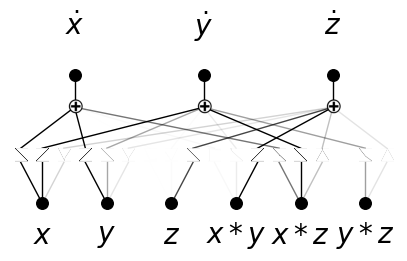

saving model version 0.2
saving model version 0.3
saving model version 0.4
saving model version 0.5
saving model version 0.6
saving model version 0.7
saving model version 0.8
saving model version 0.9
saving model version 0.10
saving model version 0.11
saving model version 0.12
saving model version 0.13
saving model version 0.14
saving model version 0.15
saving model version 0.16
saving model version 0.17
saving model version 0.18
saving model version 0.19
saving model version 0.20
saving model version 0.20
Symbolic formula extracted.


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


True Lorenz equations (σ=10, ρ=28, β=8/3):
dx/dt = 10(y - x)
dy/dt = x(28 - z) - y
dz/dt = xy - (8/3)z


In [4]:
# ============================================================
#  Generate Lorenz data + KANDy-based system discovery
# - Generates (t_train, X_train_np) for Lorenz (x,y,z)
# - Fits KAN: (library features -> [x_dot, y_dot, z_dot])
# - Adds integrator rollout training.
# ============================================================

import numpy as np
import torch
from kan import KAN

import sympy as sp
import sympy
from sympy import Eq
from sympy.printing.latex import latex
from IPython.display import display, Math
import matplotlib.pyplot as plt

# -----------------------
# 0) Device
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# -----------------------
# 1) Generate Lorenz data (RK4)
# -----------------------
def lorenz_rhs(state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz], dtype=np.float64)

def rk4_step(f, y, t, dt, **kwargs):
    k1 = f(y, **kwargs)
    k2 = f(y + 0.5*dt*k1, **kwargs)
    k3 = f(y + 0.5*dt*k2, **kwargs)
    k4 = f(y + dt*k3, **kwargs)
    return y + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

# ---- Lorenz parameters (edit if you like)
sigma = 10.0
rho   = 28.0
beta  = 8.0/3.0

# ---- time grid (fine) then subsample snapshots (sparse like your PDE case)
T      = 50.0
dt     = 0.005          # integration step
stride = 1             # take every 'stride' steps as snapshot
burn_in = 2.0           # optional transient drop (seconds)

x0 = np.array([1.0, 1.0, 1.0], dtype=np.float64)

n_steps = int(np.round(T/dt))
t_fine = np.linspace(0.0, T, n_steps + 1, dtype=np.float64)

traj = np.zeros((n_steps + 1, 3), dtype=np.float64)
traj[0] = x0

for i in range(n_steps):
    traj[i+1] = rk4_step(lorenz_rhs, traj[i], t_fine[i], dt, sigma=sigma, rho=rho, beta=beta)

# burn-in removal (optional)
burn_idx = int(np.floor(burn_in / dt))
t_fine2 = t_fine[burn_idx:]
traj2   = traj[burn_idx:]

# sparse snapshots
t_train = t_fine2[::stride].copy()
X_train_np = traj2[::stride].copy()  # (K,3)

print("Generated snapshots:", X_train_np.shape, "t_train:", t_train.shape)
print("First snapshot [x,y,z]:", X_train_np[0])

# -----------------------
# 2) Feature library builder Theta(x,y,z)
# -----------------------
def build_lorenz_library_features(x, y, z):
    feats = []
    names = []

    #feats.append(np.ones_like(x)); names.append("1")

    feats += [x, y, z]
    names += ["x", "y", "z"]

    feats += [ x*y, x*z, y*z]
    names += [ "x*y", "x*z", "y*z"]

    Theta = np.stack(feats, axis=-1)
    return Theta, names

# -----------------------
# 3) Build time-aligned training tensors + forward-diff labels
# -----------------------
X_snap = torch.tensor(X_train_np, dtype=torch.float32, device=device)  # (K,3)
t_snap = torch.tensor(t_train,    dtype=torch.float32, device=device)  # (K,)

dt_seg = (t_snap[1:] - t_snap[:-1]).unsqueeze(1)  # (K-1,1)
S_k    = X_snap[:-1]                               # (K-1,3) state at t_k
dS     = (X_snap[1:] - X_snap[:-1]) / dt_seg       # (K-1,3) approx derivatives at t_k

S_k_np = S_k.detach().cpu().numpy()
dS_np  = dS.detach().cpu().numpy()

x_np = S_k_np[:, 0]
y_np = S_k_np[:, 1]
z_np = S_k_np[:, 2]

Theta_np, feat_names = build_lorenz_library_features(x_np, y_np, z_np)  # (K-1,F)
Y_np = dS_np  # (K-1,3)

print("Library feature count:", Theta_np.shape[1])
print("Total samples (time intervals):", Theta_np.shape[0])

X = torch.tensor(Theta_np, dtype=torch.float32, device=device)
y = torch.tensor(Y_np,     dtype=torch.float32, device=device)

# normalize features
X_mean = X.mean(dim=0, keepdim=True)
X_std  = X.std(dim=0, keepdim=True) + 1e-8
Xn = X# (X - X_mean) / X_std

# train/test split
N = Xn.shape[0]
perm = torch.randperm(N, device=device)
test_frac = 0.2
N_test = max(1, int(test_frac * N))
test_idx = perm[:N_test]
train_idx = perm[N_test:]

dataset = {
    "train_input": Xn[train_idx],
    "train_label": y[train_idx],
    "test_input":  Xn[test_idx],
    "test_label":  y[test_idx],
}

# Suppose you want one long trajectory; make it (1, T, 3)
train_traj = torch.tensor(X_train_np[None, :, :], dtype=torch.float32, device=device)
train_t    = torch.tensor(t_train, dtype=torch.float32, device=device)

dataset["train_traj"] = train_traj
dataset["train_t"]    = train_t
print("dataset shapes:", {k: tuple(v.shape) for k, v in dataset.items()})

# -----------------------
# 4) Fit KAN: (n_features -> 3)
# -----------------------
n_features = Xn.shape[1]
rbf = lambda x: torch.exp(-(x**2))
rbf = lambda x: torch.exp(-(3*x**2))
kan_lorenz = KAN(width=[n_features, 3], grid=2, k=1, base_fun=rbf, seed=0).to(device)

# kan_lorenz.fit(dataset, opt="Adam",  steps=50, lr=1e-3)#, lamb=1e-4)
# kan_lorenz.fit(dataset, opt="LBFGS", steps=100,  lr=1e-3)#, lamb=1e-4)
#kan_lorenz.fit(dataset, opt="LBFGS", steps=50)#,  lr=1e-2)#, lamb=1e-4)
def dynamics_fn(state):
    # state: (B,3) torch
    x, y, z = state[:,0], state[:,1], state[:,2]
    Theta = torch.stack([x, y, z, x*y, x*z, y*z], dim=1)  # (B,6)

    Theta_n = (Theta - X_mean.squeeze(0)) / X_std.squeeze(0)  # use your saved stats
    return kan_lorenz.forward(Theta_n)  # (B,3) derivative

#kan_lorenz.fit(dataset, opt="Adam", steps=100)
fit(kan_lorenz,
    dataset,
    opt="LBFGS",
    steps=300,
    lr=1e-3,
    rollout_weight=1.0,     # turn on integration loss
    rollout_horizon=10,
    dynamics_fn=dynamics_fn,
    integrator="rk4",
    stop_grid_update_step=300
)
#kan_lorenz.fit(dataset, opt="Adam", steps=20,  lr=1e-3)#, lamb=1e-4)

# -----------------------
# 5) Sanity check
# -----------------------
with torch.no_grad():
    yhat = kan_lorenz(Xn).detach().cpu().numpy()
    ytrue = y.detach().cpu().numpy()

mse_all = np.mean((yhat - ytrue)**2)
mse_xyz = np.mean((yhat - ytrue)**2, axis=0)
print("\nOverall MSE:", float(mse_all))
print("Per-output MSE [dx/dt, dy/dt, dz/dt]:", [float(v) for v in mse_xyz])

# -----------------------
# 6) Plot + Symbolic extraction (robust, correct symbols even with lib=['x'])
# -----------------------
model = kan_lorenz
model.save_act = True
n_in = int(model.width_in[0])

in_vars_latex_full = [rf"${nm}$" for nm in feat_names]
out_vars_latex = [r"$\dot x$", r"$\dot y$", r"$\dot z$"]

# IMPORTANT: use SymPy symbols (not strings) for your feature semantics
x, y, z = sp.symbols("x y z")
feature_syms_full = [
    x, y, z,
    x*y, x*z, y*z,
]

if n_in > len(in_vars_latex_full):
    raise ValueError(f"Model expects {n_in} inputs but you only provided {len(in_vars_latex_full)}.")

in_vars_latex = in_vars_latex_full[:n_in]
feature_syms  = feature_syms_full[:n_in]


_ = model(dataset["train_input"])
model.plot(beta=10, in_vars=in_vars_latex, out_vars=out_vars_latex)

plt.savefig(
    "figs/lorenz_model.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

model = kan_lorenz
model.unfix_symbolic_all()
model.save_act = True
_ = model(dataset["train_input"])
model.prune()

# model_sym, rep = robust_auto_symbolic(
#     model,
#     simple_lib=['x','x^2','x^3','0'],   # or pass your SYMBOLIC_LIB dict if your KAN expects dict
#     complex_lib=['x','x^2','0'],
#     # r2_threshold=0.85,
#     # weight_simple=0.85,
#     weight_simple=0.73,
#     r2_threshold=0.98,
#     keep="topk",
#     topk_edges=64,
#     max_total_complexity=100,           # optional
#     verbose=1,
#     inplace=True
# )

model_sym = robust_auto_symbolic(
    model,
    #dataset=dataset,
    lib=['x','x^2','x^3','0'],
    weight_simple=0.73,
    r2_threshold=0.98,
    #topk_edges=64,
    #max_total_complexity=100,
)
#print(rep)
raw = model_sym.symbolic_formula()
print("Symbolic formula extracted.")
exprs_raw, vars_ = model.symbolic_formula()

# vars_ might be a list like [x_1, x_2, ..., x_n]; its order matches model inputs.
# Build a deterministic substitution map from those vars_ to your semantic feature symbols.
if len(vars_) < n_in:
    raise ValueError(f"symbolic_formula returned only {len(vars_)} vars, but model has n_in={n_in}")

sub_map = {vars_[i]: feature_syms[i] for i in range(n_in)}

def round_numbers(expr, places=3):
    repl = {}
    for a in expr.atoms(sp.Number):
        try:
            repl[a] = sp.Float(round(float(a), places))
        except Exception:
            pass
    return expr.xreplace(repl)

# Ensure we have a flat list of 3 expressions
# Some KAN versions return nested lists; handle both.
def flatten(obj):
    if isinstance(obj, (list, tuple)):
        out = []
        for it in obj:
            out.extend(flatten(it))
        return out
    return [obj]

exprs_list = flatten(exprs_raw)

def prune_small_terms(obj, tol=1e-3):
    # handle lists/tuples of expressions
    if isinstance(obj, (list, tuple)):
        return [prune_small_terms(e, tol=tol) for e in obj]

    expr = sp.expand(obj)

    kept = []
    for term in expr.as_ordered_terms():
        coeff, rest = term.as_coeff_Mul()
        try:
            if abs(float(coeff)) >= tol:
                kept.append(term)
        except Exception:
            # non-numeric coefficient; keep the term
            kept.append(term)

    return sp.Add(*kept)


exprs_list = prune_small_terms(exprs_list, tol=1e-1)

# Substitute using vars_ (NOT free_symbols inference)
cleaned = []
for expr in exprs_list:
    if not hasattr(expr, "free_symbols"):
        continue
    expr_sub = expr.subs(sub_map)                 # <-- the key fix
    expr_sub = sp.together(sp.expand(expr_sub))
    expr_sub = round_numbers(expr_sub, 3)
    cleaned.append(expr_sub)

# Display
xd, yd, zd = sp.symbols(r"\dot{x} \dot{y} \dot{z}")
if len(cleaned) >= 3:
    display(Math(latex(Eq(xd, cleaned[0]))))
    display(Math(latex(Eq(yd, cleaned[1]))))
    display(Math(latex(Eq(zd, cleaned[2]))))
else:
    lines = []
    for k, ex in enumerate(cleaned):
        lines.append(latex(Eq(sp.Symbol(f"y_{k}"), ex)))
    display(Math(r"\begin{cases}" + r"\ ".join(lines) + r"\end{cases}"))

print("\nTrue Lorenz equations (σ=10, ρ=28, β=8/3):")
print("dx/dt = 10(y - x)")
print("dy/dt = x(28 - z) - y")
print("dz/dt = xy - (8/3)z")

In [ ]:
"""
Publication-quality Lorenz attractor comparison – 2-D projection (x–z plane).
  • True system: full long trajectory (light grey, background)
  • KAN rollout: short segment – one loop around each lobe (solid black)
  • Symbolic:    short segment – one loop around each lobe (dashed dark grey)
"""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────
# 0.  Matplotlib config
# ──────────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":   "cm",
    "font.size":          9,
    "axes.labelsize":     11,
    "axes.titlesize":     11,
    "legend.fontsize":    8.5,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.major.size":   3.5,
    "ytick.major.size":   3.5,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "axes.linewidth":     0.7,
    "savefig.dpi":        600,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
    "figure.dpi":         150,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

# ──────────────────────────────────────────────────────────────
# 1.  RK4 integrator
# ──────────────────────────────────────────────────────────────
def rk4_integrate(rhs, y0, t_span, dt):
    t = t_span[0]
    y = np.array(y0, dtype=np.float64)
    ts, ys = [t], [y.copy()]
    while t < t_span[1] - 1e-12:
        h = min(dt, t_span[1] - t)
        k1 = rhs(y)
        k2 = rhs(y + 0.5 * h * k1)
        k3 = rhs(y + 0.5 * h * k2)
        k4 = rhs(y + h * k3)
        y  = y + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        t += h
        ts.append(t)
        ys.append(y.copy())
    return np.array(ts), np.array(ys)

# ──────────────────────────────────────────────────────────────
# 2.  Define the three RHS functions
# ──────────────────────────────────────────────────────────────
sigma, rho, beta = 10.0, 28.0, 8.0 / 3.0

def lorenz_true(s):
    x, y, z = s
    return np.array([sigma*(y - x), x*(rho - z) - y, x*y - beta*z])


def lorenz_kan(s):
    x, y, z = map(float, s)

    Theta = torch.tensor([[x, y, z, x*y, x*z, y*z]],
                         dtype=torch.float32, device=device)

    # IMPORTANT: match training (you used Xn = X)
    Theta_n = Theta

    with torch.no_grad():
        ds = kan_lorenz(Theta_n)

    return ds.squeeze(0).cpu().numpy()

def lorenz_symbolic(s):
    """
    KANDy learned formula
    𝑥˙=−8.906𝑥+9.68𝑦
    𝑦˙=−0.987𝑥𝑧+28.037𝑥−0.7𝑦+0.818
    𝑧˙=1.002𝑥𝑦−2.505𝑧−4.029
    """
    x, y, z = s
    return np.array([
        -8.906*x + 9.68*y,
        28.037*x - 0.987*x*z - 0.7*y + 0.818,
        1.002*x*y - 2.505*z - 4.026])

# ──────────────────────────────────────────────────────────────
# 3.  Generate trajectories
# ──────────────────────────────────────────────────────────────
dt_int = 0.005

# --- Full true trajectory (long, for background) ---
y0_full = np.array([1.0, 1.0, 1.0])
T_full  = 50.0
burn    = 2.0
i_burn  = int(burn / dt_int)

_, traj_true_full = rk4_integrate(lorenz_true, y0_full, [0, T_full], dt_int)
traj_true_full = traj_true_full[i_burn:]

# --- Helper: extract a segment that makes ~one loop per lobe ---
# Strategy: pick a starting point already on the attractor, integrate
# just long enough to loop once around each lobe (~1.5 Lorenz periods).
# One full figure-8 takes roughly T≈1.5–2.0 s on the standard attractor.

# Use a point from the settled attractor as IC for the short segments
ic_short = traj_true_full[2000].copy()  # well on the attractor
T_short  = 3.0  # ~one figure-8 loop

t_kan, traj_kan   = rk4_integrate(lorenz_kan,      ic_short, [0, T_short], dt_int)
t_sym, traj_sym   = rk4_integrate(lorenz_symbolic,  ic_short, [0, T_short], dt_int)
t_ref, traj_ref   = rk4_integrate(lorenz_true,      ic_short, [0, T_short], dt_int)

# ──────────────────────────────────────────────────────────────
# 4.  Build figure
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.0, 3.3))

# (a) Full true attractor – light grey background
ax.plot(traj_true_full[:, 0], traj_true_full[:, 2],
        color="#B8B8B8", lw=0.5, alpha=0.50,
        zorder=1, label="True system", rasterized=True)

# (b) KAN rollout – solid black, one figure-8
ax.plot(traj_kan[:, 0], traj_kan[:, 2],
        color="#111111", lw=1.1, alpha=0.92,
        solid_capstyle="round",
        zorder=3, label="KANDy rollout")

# (c) Symbolic – dashed dark grey, one figure-8
ax.plot(traj_sym[:, 0], traj_sym[:, 2],
        color="#555555", lw=1.1, alpha=0.88,
        ls=(0, (5, 2.5)),
        solid_capstyle="round", dash_capstyle="round",
        zorder=2, label="KANDy Symbolic")



# ── Axes ──
ax.set_xlabel(r"$x$", fontsize=30)
ax.set_ylabel(r"$z$", fontsize=30, rotation=0)
ax.set_xlim(-25, 25)
ax.set_ylim(0, 55)
ax.set_xticks([-20, -10, 0, 10, 20])
ax.set_yticks([0, 10, 20, 30, 40, 50])

# ── Equation box (upper-right) ──
# eq_text = (
#     r"$\dot{x} = 10(y - x)$" + "\n"
#     r"$\dot{y} = x(28 - z) - y$" + "\n"
#     r"$\dot{z} = xy - \dfrac{8}{3}\,z$"
# )
eq_text = (
    r"$\dot{x} = 9.68\,(y - 0.92\,x)$" + "\n"
    r"$\dot{y} = x(28.037 - 0.987\,z) - 0.7\,y + 0.818$" + "\n"
    r"$\dot{z} = 1.002\,x y - 2.505\,z - 4.026$"
)
ax.text(
    0.97, 0.97, eq_text,
    transform=ax.transAxes,
    fontsize=8.5, va="top", ha="right",
    linespacing=1.65,
    bbox=dict(boxstyle="square,pad=0.35",
              facecolor="white", edgecolor="#888888",
              linewidth=0.5, alpha=0.92),
)

# ── Legend ──
leg = ax.legend(
    loc="upper left",
    frameon=True, framealpha=0.92,
    edgecolor="#888888", fancybox=False,
    borderpad=0.4, handlelength=2.0,
    handletextpad=0.5, fontsize=8,
)
leg.get_frame().set_linewidth(0.5)
for line in leg.get_lines():
    line.set_linewidth(1.8)
    line.set_alpha(1.0)



ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(pad=0.4)
fig.savefig("figs/lorenz_attractors.pdf", format="pdf")
fig.savefig("figs/lorenz_attractors.png", format="png", dpi=600)
plt.show()
plt.close(fig)

In [6]:
import matplotlib as mpl

mpl.rcParams.update({
    # Base font
    "font.size": 14,

    # Axes
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "axes.titlepad": 10,

    # Ticks
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    # Legend
    "legend.fontsize": 30,
    "legend.title_fontsize": 14,
    "legend.frameon": True,

    # Lines
    "lines.linewidth": 2.0,
    "lines.markersize": 6,

    # Grid
    "grid.linewidth": 0.8,

    # Figure
    "figure.titlesize": 20,
    "figure.dpi": 300,

    # PDF / SIAM-friendly output
    "pdf.fonttype": 42,   # TrueType fonts (avoids Type 3)
    "ps.fonttype": 42,
})


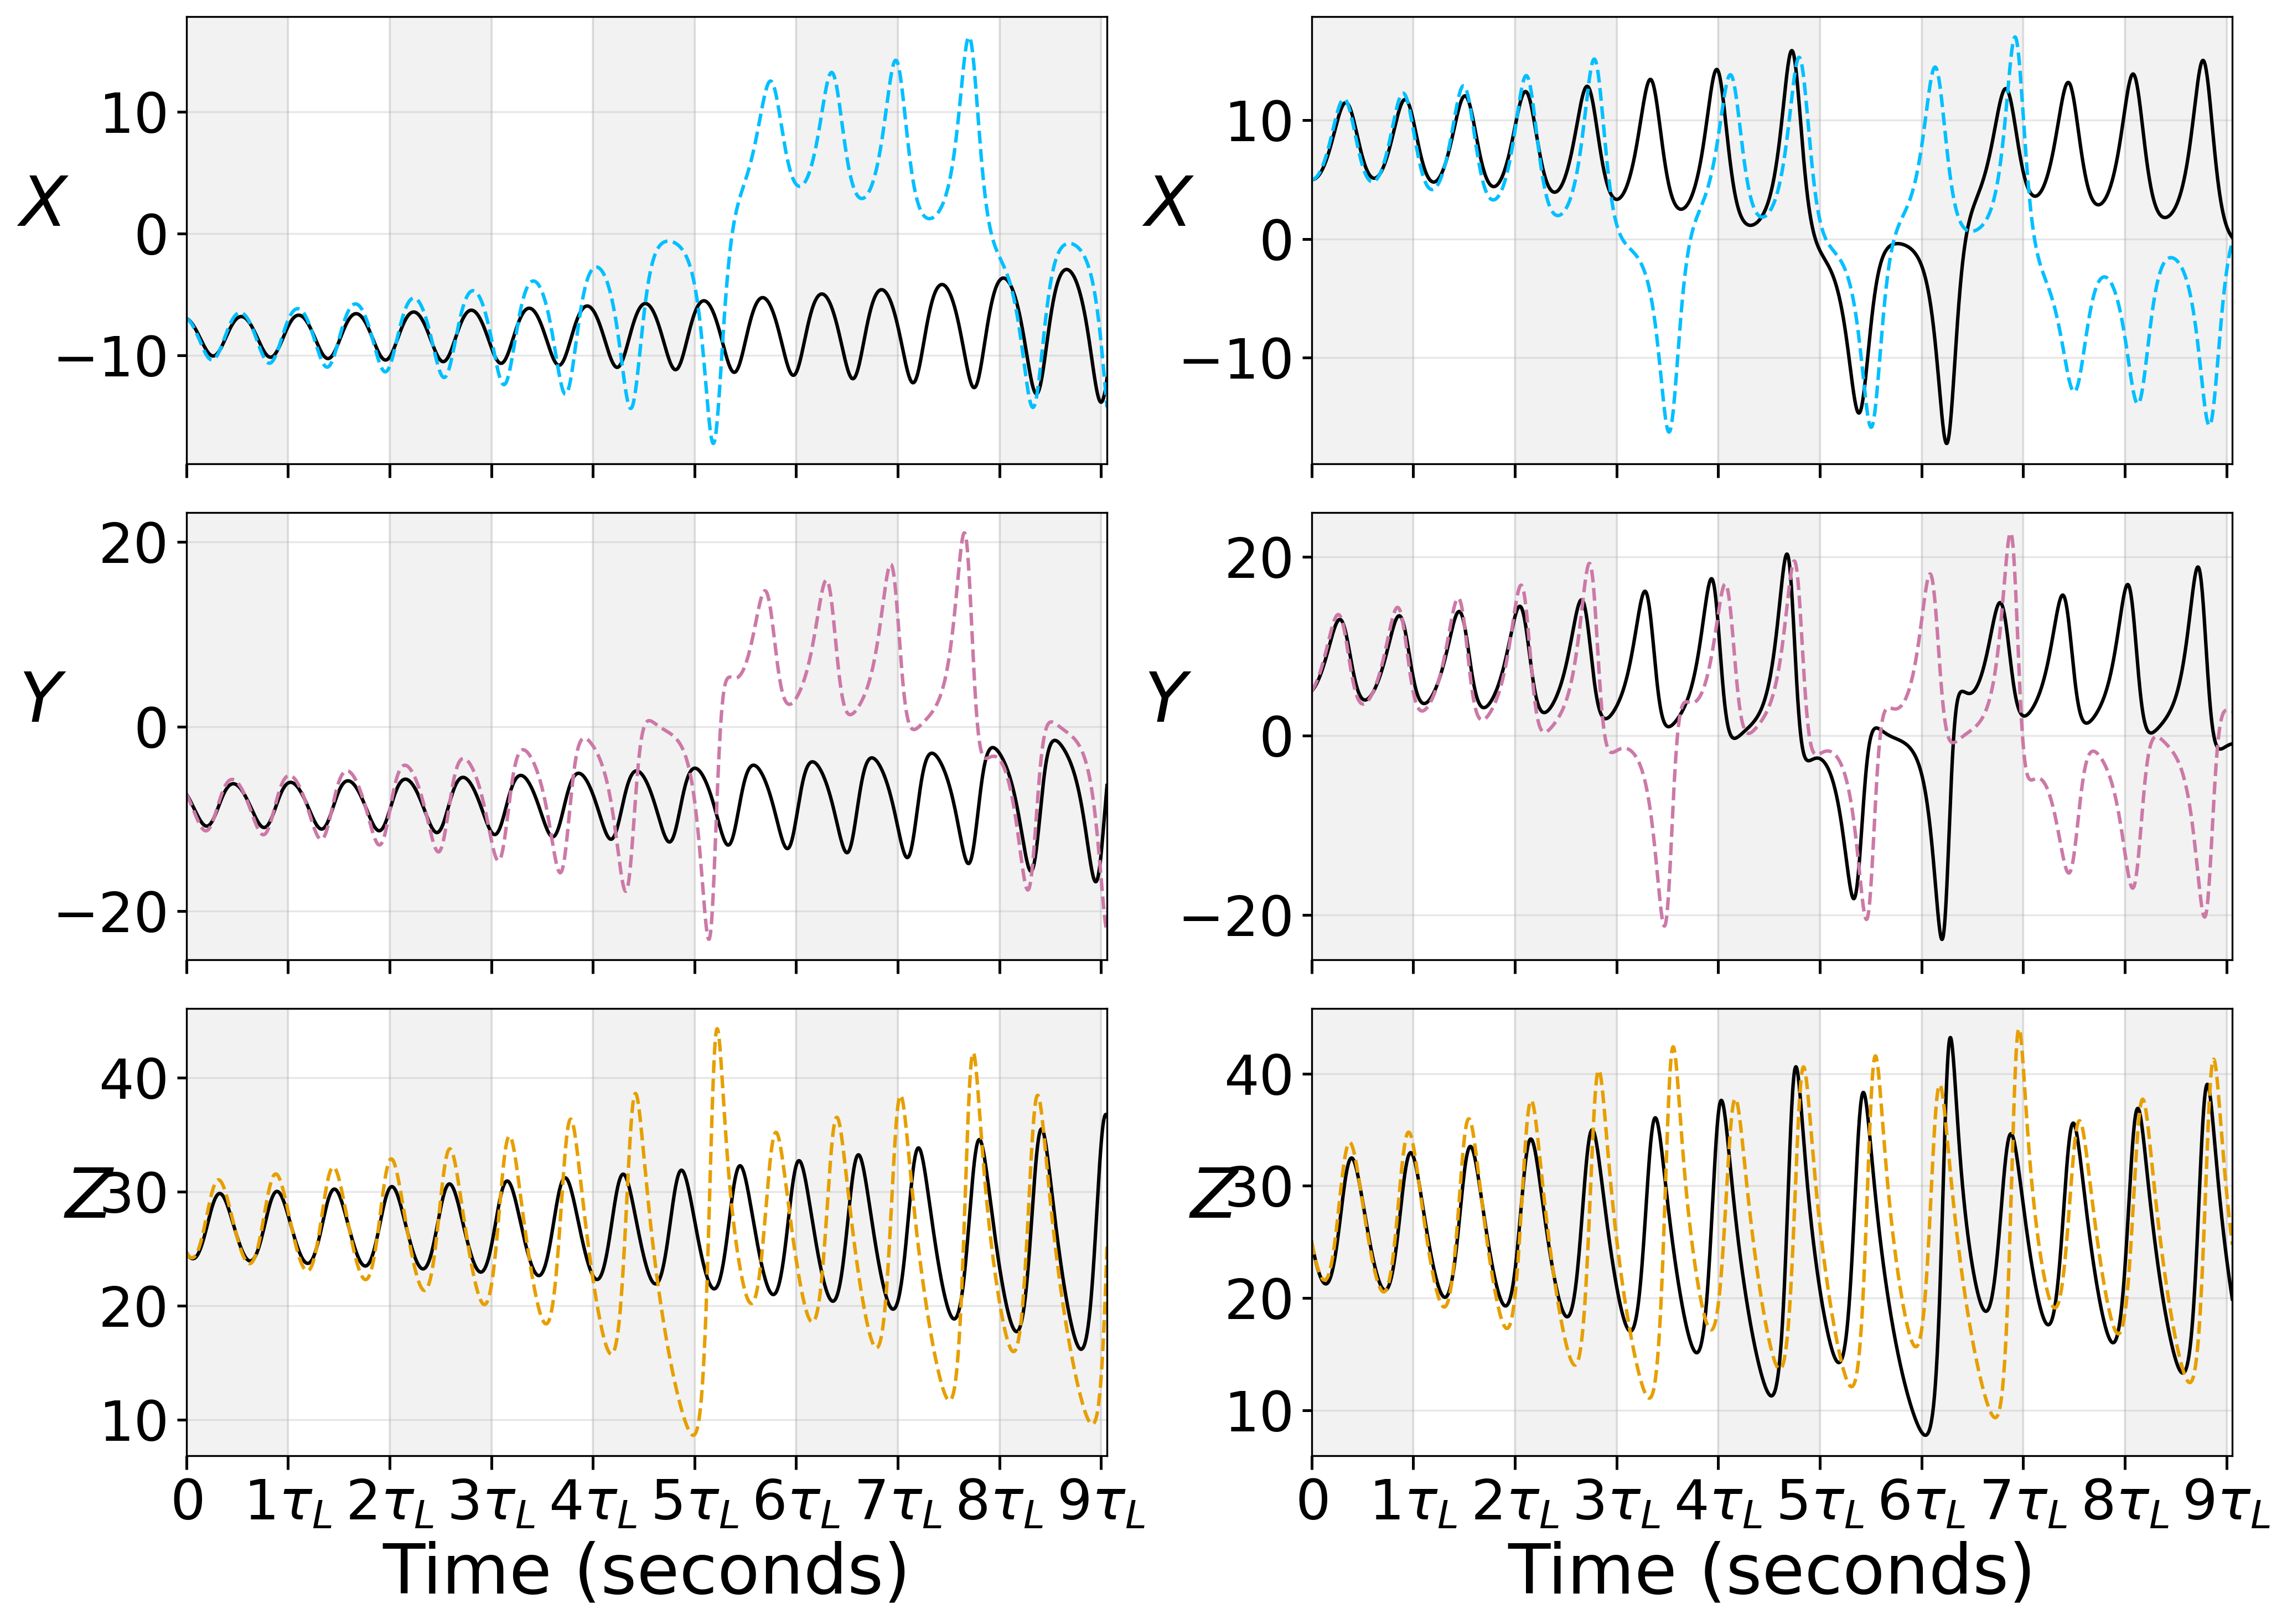


Lyapunov time τ_L = 1.104 time units
Plot duration: 10.0 seconds = 9.1 Lyapunov times


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Lyapunov time for Lorenz system
tau_L = 1.104  # Lyapunov time in time units

# Define dynamics function for rollout
def dynamics_fn_rollout(state):
    """state: (B,3) torch tensor -> returns (B,3) derivatives"""
    x, y, z = state[:, 0], state[:, 1], state[:, 2]
    Theta = torch.stack([x, y, z, x*y, x*z, y*z], dim=1)
    return kan_lorenz.forward(Theta)

# RK4 integrator for KAN model
def rk4_step_torch(f, y, dt):
    k1 = f(y)
    k2 = f(y + 0.5*dt*k1)
    k3 = f(y + 0.5*dt*k2)
    k4 = f(y + dt*k3)
    return y + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def rollout_kan(initial_state, t_eval, dt_integrate=0.005):
    """Rollout KAN model from initial_state over t_eval times"""
    with torch.no_grad():
        state = torch.tensor(initial_state, dtype=torch.float32, device=device).unsqueeze(0)
        trajectory = [state.cpu().numpy().squeeze()]

        t_current = t_eval[0]
        for t_next in t_eval[1:]:
            while t_current < t_next - 1e-9:
                dt_step = min(dt_integrate, t_next - t_current)
                state = rk4_step_torch(dynamics_fn_rollout, state, dt_step)
                t_current += dt_step
            trajectory.append(state.cpu().numpy().squeeze())

        return np.array(trajectory)

# Generate true trajectories for in-distribution and out-of-distribution
T_plot = 10.0
dt_plot = 0.005
n_plot_steps = int(T_plot / dt_plot)
t_plot = np.linspace(0, T_plot, n_plot_steps + 1)

# In-distribution: use a point from the training trajectory (after burn-in)
ic_in_dist = X_train_np[100].copy()  # Pick a point from training data

# Out-of-distribution: different initial condition
ic_ood = np.array([5.0, 5.0, 25.0], dtype=np.float64)  # Different IC

# Generate true trajectories
def generate_true_trajectory(ic, t_array, dt):
    traj = np.zeros((len(t_array), 3))
    traj[0] = ic
    for i in range(len(t_array) - 1):
        traj[i+1] = rk4_step(lorenz_rhs, traj[i], t_array[i], dt, sigma=sigma, rho=rho, beta=beta)
    return traj

true_in_dist = generate_true_trajectory(ic_in_dist, t_plot, dt_plot)
true_ood = generate_true_trajectory(ic_ood, t_plot, dt_plot)

# Generate KAN predictions
kan_in_dist = rollout_kan(ic_in_dist, t_plot, dt_integrate=dt_plot)
kan_ood = rollout_kan(ic_ood, t_plot, dt_integrate=dt_plot)

# -----------------------
# Plotting
# -----------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)

# Colors matching the image
colors_kan = ['#4DBEEE', '#D55E00', '#F0A000']  # Cyan, Magenta-ish, Orange-yellow
colors_true = ['#2D2D2D', '#2D2D2D', '#2D2D2D']  # Dark gray

# Actually match the image colors more closely
kan_colors = ['#00BFFF', '#CC79A7', '#E69F00']  # Cyan, Pink/Magenta, Orange
labels = [r'$X$', r'$Y$', r'$Z$']
titles = ['In-Distribution', 'Out-of-Distribution']

n_tau = int(np.floor(T_plot / tau_L))
tau_ticks = np.arange(0, n_tau + 1) * tau_L

# LaTeX tick labels
tau_ticklabels = [r'$0$'] + [rf'${i}\tau_L$' for i in range(1, n_tau + 1)]

data_pairs = [
    (true_in_dist, kan_in_dist),
    (true_ood, kan_ood)
]

for col, (true_data, kan_data) in enumerate(data_pairs):
    for row in range(3):
        ax = axes[row, col]

        # Add alternating shaded regions for Lyapunov times
        n_intervals = int(np.ceil(T_plot / tau_L)) + 1
        for i in range(n_intervals):
            t_start = i * tau_L
            t_end = (i + 1) * tau_L
            if i % 2 == 0:
                ax.axvspan(t_start, t_end, alpha=0.1, color='gray')

        # Plot true trajectory
        ax.plot(t_plot, true_data[:, row], 'k-', linewidth=1.5, label='True')

        # Plot KAN prediction
        ax.plot(t_plot, kan_data[:, row], '--', color=kan_colors[row], linewidth=1.5, label='KANDy')

        ax.set_ylabel(labels[row], fontsize=30, rotation=0)


        ax.set_xlim(0, T_plot)
        ax.grid(True, alpha=0.3)
        
        ax.tick_params(
            axis='y',
            labelsize=24,   # bigger tick labels
            length=4,       # shorter tick marks
            width=1.2       # optional: thinner ticks
        )


# # Add Lyapunov time labels after setting y-limits
# for col in range(2):
#     for row in range(3):
#         ax = axes[row, col]
#         ylim = ax.get_ylim()
#         y_top = ylim[1]
#         n_intervals = int(np.ceil(T_plot / tau_L)) + 1
#         for i in range(n_intervals):
#             t_mid = i * tau_L + tau_L/2
#             if t_mid <= T_plot:
#                 ax.text(t_mid, y_top * 0.95, f'{i+1}τ_L', ha='center', va='top', fontsize=7, alpha=0.6)

axes[2, 0].set_xlabel('Time (seconds)', fontsize=30)
axes[2, 1].set_xlabel('Time (seconds)', fontsize=30)

#plt.suptitle(f'KAN Lorenz Predictions with Lyapunov Time Intervals\nτ_L = {tau_L} time units (shaded regions show alternating Lyapunov times)',
#             fontsize=14, y=1.02)
for col in range(2):
    ax = axes[2, col]
    ax.set_xticks(tau_ticks)
    ax.set_xticklabels(tau_ticklabels, fontsize=24)
    
plt.tight_layout()
#plt.savefig('figs/Lorenz_rollout.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nLyapunov time τ_L = {tau_L} time units")
print(f"Plot duration: {T_plot} seconds = {T_plot/tau_L:.1f} Lyapunov times")

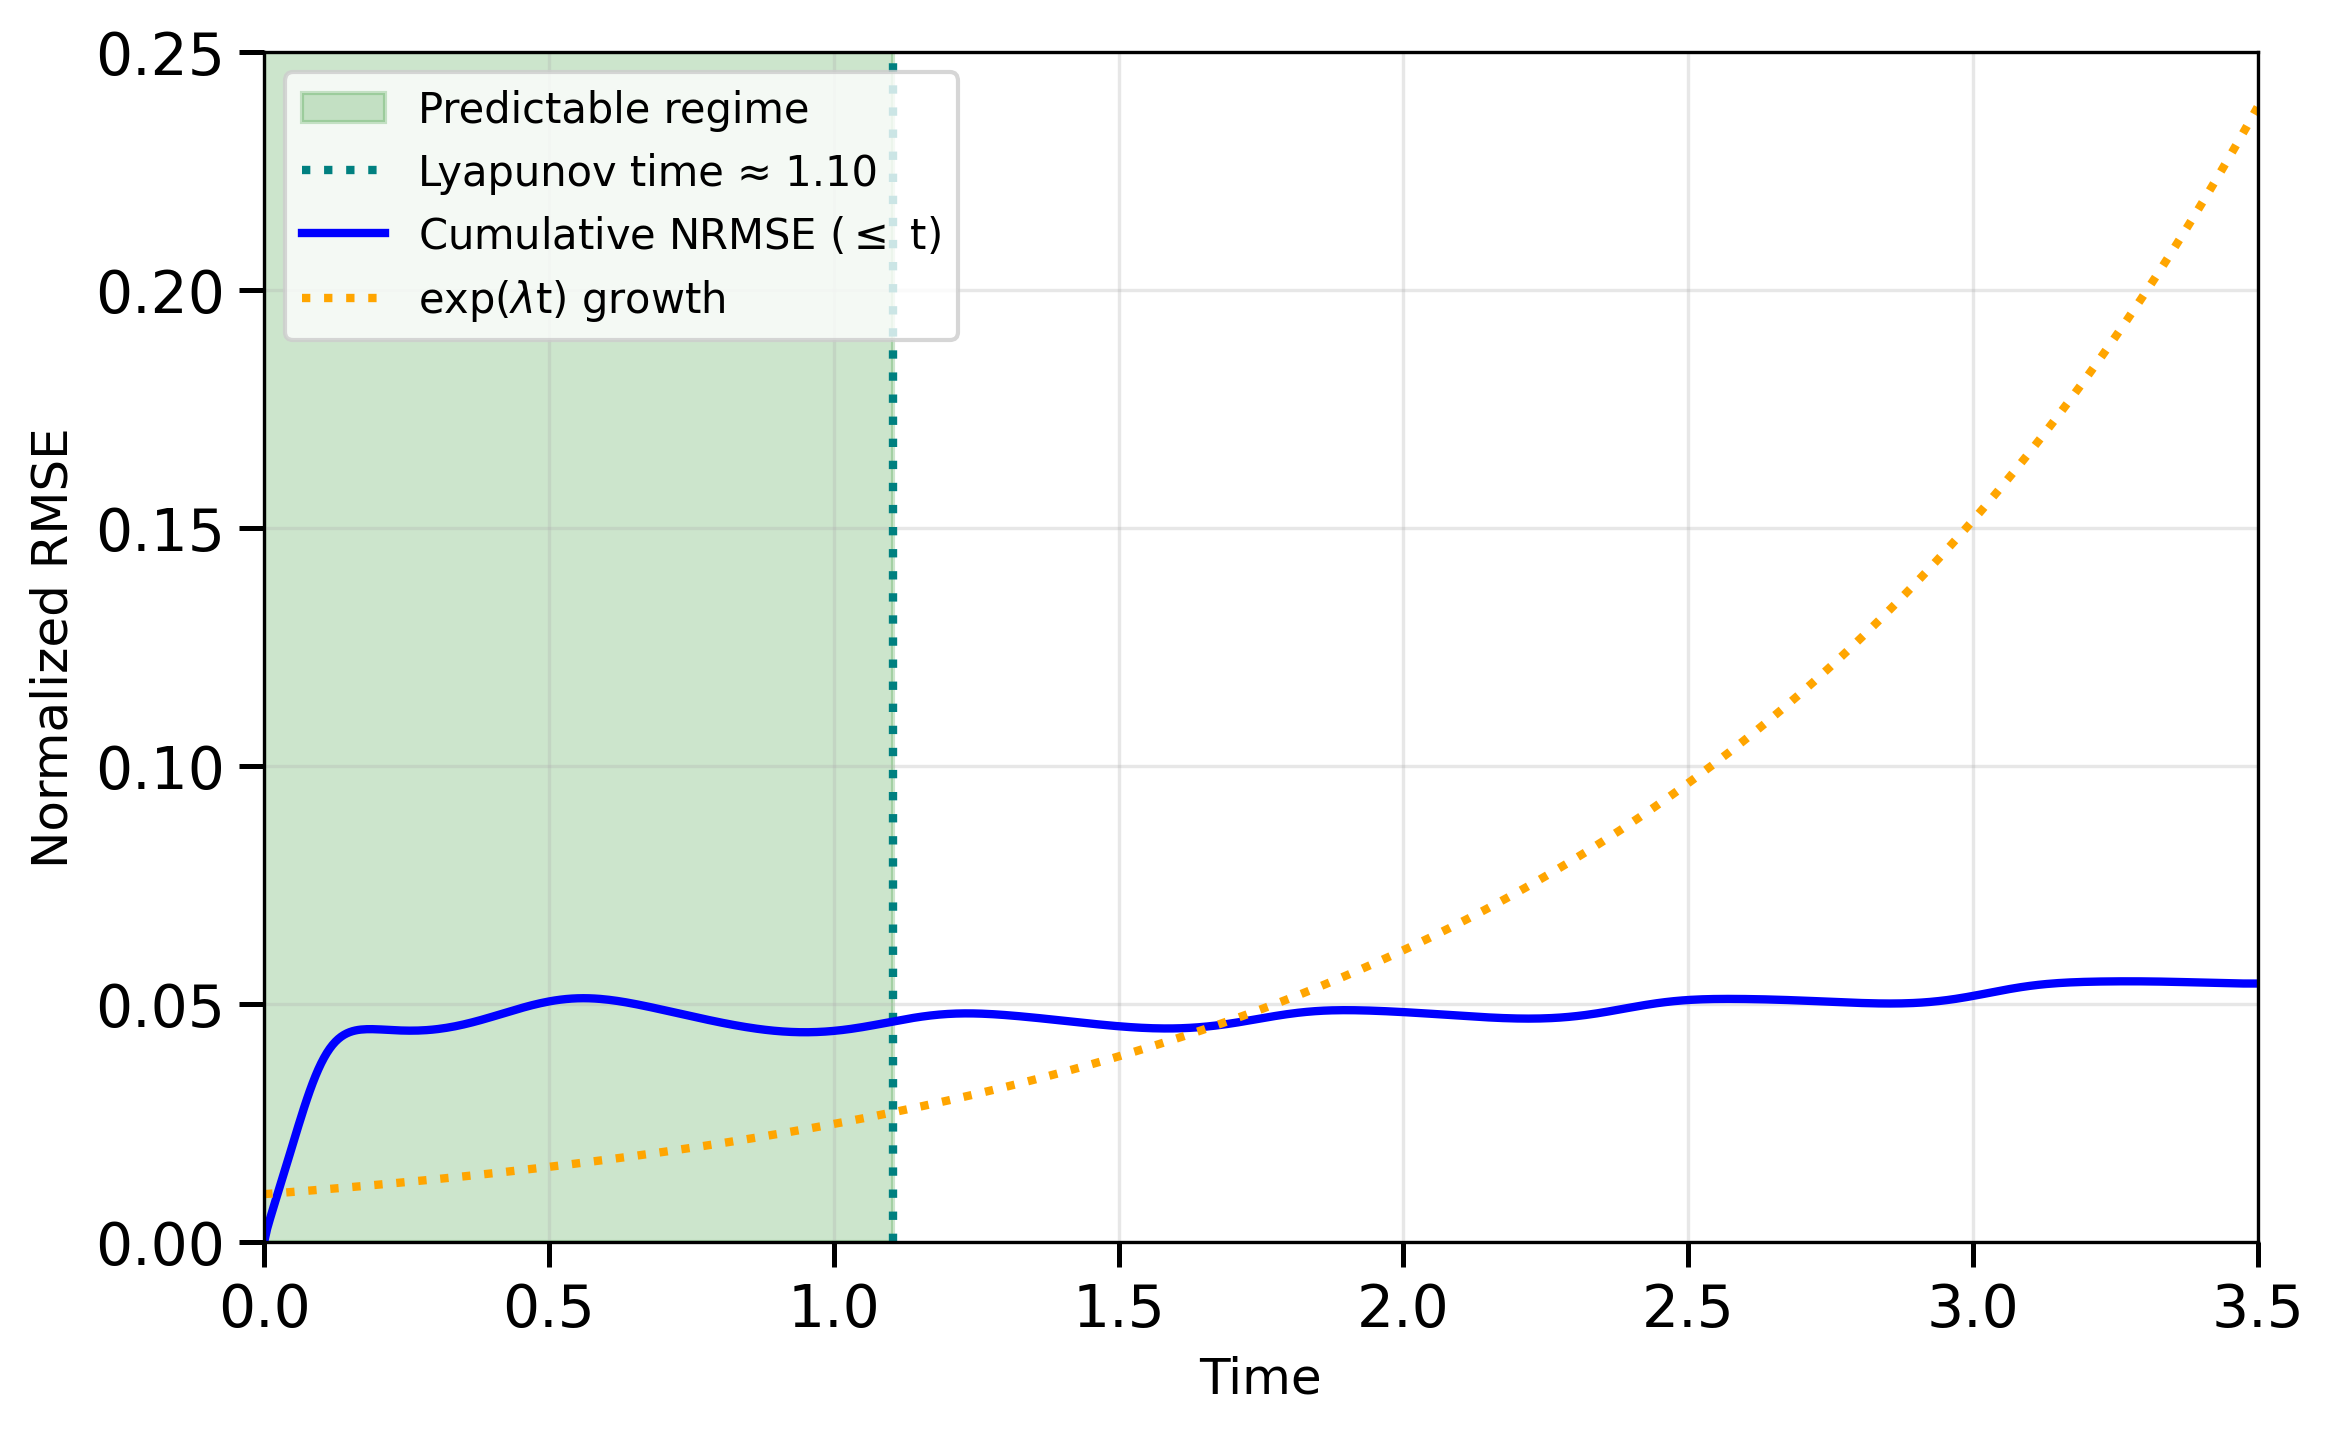

Lyapunov exponent λ = 0.906
Lyapunov time τ_L = 1/λ ≈ 1.104
Final cumulative NRMSE: 0.054
Error at Lyapunov time: 0.046


In [8]:
# -----------------------
# 9) Forecast Error vs Time with Lyapunov Time Annotation
# -----------------------
import matplotlib.pyplot as plt
import numpy as np

# Lyapunov exponent and time for Lorenz system
lambda_max = 0.906  # Largest Lyapunov exponent for Lorenz (standard parameters)
tau_L = 1.0 / lambda_max  # Lyapunov time ≈ 1.104

# Generate trajectories for error analysis
T_error = 3.5  # Time duration for error analysis
dt_error = 0.005
n_error_steps = int(T_error / dt_error)
t_error = np.linspace(0, T_error, n_error_steps + 1)

# Use an initial condition
ic_error = np.array([1.0, 1.0, 1.0], dtype=np.float64)
ic_error = np.array([25.0, 5.0, 4.0], dtype=np.float64) # OOD


# Generate true and KAN trajectories
true_traj_error = generate_true_trajectory(ic_error, t_error, dt_error)
kan_traj_error = rollout_kan(ic_error, t_error, dt_integrate=dt_error)

# Compute error at each time step
# RMSE across the 3 components at each time
error = np.sqrt(np.mean((kan_traj_error - true_traj_error)**2, axis=1))

# Normalize by the standard deviation of the true trajectory (for NRMSE)
true_std = np.std(true_traj_error)
nrmse = error / true_std

# Compute cumulative NRMSE (error accumulated up to time t)
cumulative_nrmse = np.zeros_like(nrmse)
for i in range(len(nrmse)):
    cumulative_nrmse[i] = np.sqrt(np.mean(error[:i+1]**2)) / true_std

# Exponential growth reference: exp(λt) scaled to match initial error
initial_error = max(nrmse[0], 0.01)  # Avoid zero
exp_growth = initial_error * np.exp(lambda_max * t_error)

# -----------------------
# Plotting
# -----------------------
fig, ax = plt.subplots(figsize=(8, 5))

# Shaded region for predictable regime (before Lyapunov time)
ax.axvspan(0, tau_L, alpha=0.2, color='green', label='Predictable regime')

# Vertical line at Lyapunov time
ax.axvline(x=tau_L, color='teal', linestyle=':', linewidth=2, label=f'Lyapunov time ≈ {tau_L:.2f}')

# Plot cumulative NRMSE
ax.plot(t_error, cumulative_nrmse, 'b-', linewidth=2, label=r'Cumulative NRMSE ($\leq$ t)')

# Plot exponential growth reference
ax.plot(t_error, exp_growth, 'orange', linestyle=':', linewidth=2, label=r'exp($\lambda$t) growth')

# Formatting
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Normalized RMSE', fontsize=12)
#ax.set_title('Forecast error vs time (Lyapunov time annotated)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)

# Set axis limits
ax.set_xlim(0, T_error)
ax.set_ylim(0, max(cumulative_nrmse.max(), 0.25))

# Grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figs/Lorenz_forecast_error.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Lyapunov exponent λ = {lambda_max}")
print(f"Lyapunov time τ_L = 1/λ ≈ {tau_L:.3f}")
print(f"Final cumulative NRMSE: {cumulative_nrmse[-1]:.3f}")
print(f"Error at Lyapunov time: {cumulative_nrmse[int(tau_L/dt_error)]:.3f}")

In [ ]:
model.save_act=True
_ = model(dataset["train_input"])
model.plot(beta=10, in_vars=in_vars_latex, out_vars=out_vars_latex)

plt.savefig(
    "figs/lorenz_model.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

In [9]:
# ============================================================
# Ablation Study Cell (REWRITTEN)
# - Calls robust_auto_symbolic correctly (keyword args only)
# - Passes LIST libs (not dicts) to robust_auto_symbolic / suggest_symbolic
# - Uses rep returned by robust_auto_symbolic for feature keep/zero analysis
# ============================================================

import numpy as np
import torch
from kan import KAN
import sympy as sp
from sympy import Eq
import matplotlib.pyplot as plt

# -----------------------
# Device
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------
# Generate Lorenz data
# -----------------------
def lorenz_rhs(state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz], dtype=np.float64)

def rk4_step_np(f, y, t, dt, **kwargs):
    k1 = f(y, **kwargs)
    k2 = f(y + 0.5*dt*k1, **kwargs)
    k3 = f(y + 0.5*dt*k2, **kwargs)
    k4 = f(y + dt*k3, **kwargs)
    return y + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

sigma, rho, beta = 10.0, 28.0, 8.0/3.0
T, dt, stride, burn_in = 25.0, 0.005, 1, 2.0
x0 = np.array([1.0, 1.0, 1.0], dtype=np.float64)

n_steps = int(np.round(T/dt))
t_fine = np.linspace(0.0, T, n_steps + 1, dtype=np.float64)
traj = np.zeros((n_steps + 1, 3), dtype=np.float64)
traj[0] = x0

for i in range(n_steps):
    traj[i+1] = rk4_step_np(lorenz_rhs, traj[i], t_fine[i], dt, sigma=sigma, rho=rho, beta=beta)

burn_idx = int(np.floor(burn_in / dt))
t_train = t_fine[burn_idx::stride].copy()
X_train_np = traj[burn_idx::stride].copy()
print(f"Generated snapshots: {X_train_np.shape}, t_train: {t_train.shape}")

# -----------------------
# Feature Libraries
# Each returns: (Theta_np, feat_names, feature_syms)
# -----------------------
def library_ground_truth(x, y, z):
    feats = [x, y, z, x*y, x*z, y*z]
    names = ["x", "y", "z", "xy", "xz", "yz"]

    xs, ys, zs = sp.symbols("x y z")
    syms = [xs, ys, zs, xs*ys, xs*zs, ys*zs]
    return np.stack(feats, axis=-1), names, syms

def library_with_squares(x, y, z):
    feats = [x, y, z, x*y, x*z, y*z, x**2, y**2, z**2]
    names = ["x", "y", "z", "xy", "xz", "yz", "x^2", "y^2", "z^2"]

    xs, ys, zs = sp.symbols("x y z")
    syms = [xs, ys, zs, xs*ys, xs*zs, ys*zs, xs**2, ys**2, zs**2]
    return np.stack(feats, axis=-1), names, syms

def library_with_trig(x, y, z):
    feats = [
        x, y, z, x*y, x*z, y*z,
        np.sin(x), np.cos(x), np.sin(y), np.cos(y), np.sin(z), np.cos(z)
    ]
    names = [
        "x", "y", "z", "xy", "xz", "yz",
        "sin(x)", "cos(x)", "sin(y)", "cos(y)", "sin(z)", "cos(z)"
    ]

    xs, ys, zs = sp.symbols("x y z")
    syms = [
        xs, ys, zs, xs*ys, xs*zs, ys*zs,
        sp.sin(xs), sp.cos(xs), sp.sin(ys), sp.cos(ys), sp.sin(zs), sp.cos(zs)
    ]
    return np.stack(feats, axis=-1), names, syms

def library_with_exp(x, y, z):
    feats = [x, y, z, x*y, x*z, y*z, np.exp(x/20), np.exp(y/20), np.exp(z/20)]
    names = ["x", "y", "z", "xy", "xz", "yz", "exp(x/20)", "exp(y/20)", "exp(z/20)"]

    xs, ys, zs = sp.symbols("x y z")
    syms = [xs, ys, zs, xs*ys, xs*zs, ys*zs, sp.exp(xs/20), sp.exp(ys/20), sp.exp(zs/20)]
    return np.stack(feats, axis=-1), names, syms

# -----------------------
# Symbolic libs as LISTS (not dicts)
# These are the tokens robust_auto_symbolic will pass into model.suggest_symbolic(...)
# -----------------------
SYMLIB_BASIC_LIST = ["x", "x^2", "x^3", "0"]
SYMLIB_TRIG_LIST  = ["x", "x^2", "sin", "cos", "0"]
SYMLIB_EXP_LIST   = ["x", "x^2", "exp", "0"]

# -----------------------
# Helpers for symbolic extraction cleanup
# -----------------------
def _flatten(obj):
    if isinstance(obj, (list, tuple)):
        out = []
        for it in obj:
            out.extend(_flatten(it))
        return out
    return [obj]

def _round_numbers(expr, places=3):
    repl = {}
    for a in expr.atoms(sp.Number):
        try:
            repl[a] = sp.Float(round(float(a), places))
        except Exception:
            pass
    return expr.xreplace(repl)

# -----------------------
# Run single experiment
# -----------------------
def run_experiment(library_fn, sym_lib_list, experiment_name, seed=42):
    print(f"\n{'='*70}")
    print(f"EXPERIMENT: {experiment_name}")
    print(f"{'='*70}")

    torch.manual_seed(seed)
    np.random.seed(seed)

    # Build derivative targets from snapshots
    X_snap = torch.tensor(X_train_np, dtype=torch.float32, device=device)  # (K,3)
    t_snap = torch.tensor(t_train,    dtype=torch.float32, device=device)  # (K,)

    dt_seg = (t_snap[1:] - t_snap[:-1]).unsqueeze(1)  # (K-1,1)
    S_k    = X_snap[:-1]                               # (K-1,3)
    dS     = (X_snap[1:] - X_snap[:-1]) / dt_seg       # (K-1,3)

    S_k_np = S_k.detach().cpu().numpy()
    dS_np  = dS.detach().cpu().numpy()

    x_np, y_np, z_np = S_k_np[:, 0], S_k_np[:, 1], S_k_np[:, 2]

    # Build feature library (overcomplete if ablation)
    Theta_np, feat_names, feature_syms = library_fn(x_np, y_np, z_np)
    Y_np = dS_np

    print(f"Number of features: {Theta_np.shape[1]}")
    print("Features:", feat_names)

    X = torch.tensor(Theta_np, dtype=torch.float32, device=device)
    y = torch.tensor(Y_np,     dtype=torch.float32, device=device)

    # Train/test split
    N = X.shape[0]
    perm = torch.randperm(N, device=device)
    N_test = max(1, int(0.2 * N))
    test_idx  = perm[:N_test]
    train_idx = perm[N_test:]

    dataset = {
        "train_input": X[train_idx],
        "train_label": y[train_idx],
        "test_input":  X[test_idx],
        "test_label":  y[test_idx],
        # Rollout trajectory (single long)
        "train_traj": torch.tensor(X_train_np[None, :, :], dtype=torch.float32, device=device),
        "train_t":    torch.tensor(t_train, dtype=torch.float32, device=device),
    }

    # Model
    n_features = X.shape[1]
    rbf = lambda x: torch.exp(-(3*x**2))
    model = KAN(width=[n_features, 3], grid=2, k=1, base_fun=rbf, seed=seed).to(device)

    # Dynamics function: rebuild Theta from state using the SAME library
    def dynamics_fn(state):
        # state: (B,3)
        x = state[:, 0].detach().cpu().numpy()
        y = state[:, 1].detach().cpu().numpy()
        z = state[:, 2].detach().cpu().numpy()
        Theta_tmp, _, _ = library_fn(x, y, z)  # (B,F)
        Theta_t = torch.tensor(Theta_tmp, dtype=torch.float32, device=state.device)
        return model.forward(Theta_t)          # (B,3) derivative

    # Train
    print("\n--- Training ---")
    fit(
        model,
        dataset,
        opt="LBFGS",
        steps=300,
        lr=1e-3,
        rollout_weight=1.0,
        rollout_horizon=10,
        dynamics_fn=dynamics_fn,
        integrator="rk4",
        stop_grid_update_step=200,
        log=50
    )

    # Evaluate MSE on derivative mapping
    with torch.no_grad():
        yhat = model(X).detach().cpu().numpy()
        ytru = y.detach().cpu().numpy()
    mse_all = float(np.mean((yhat - ytru)**2))
    print(f"\nOverall MSE (derivative fit): {mse_all:.6f}")

    # -----------------------
    # Symbolic Extraction
    # -----------------------
    print("\n--- Symbolic Extraction ---")
    model.save_act = True
    _ = model(dataset["train_input"])
    model.unfix_symbolic_all()
    model.prune()

    # IMPORTANT: robust_auto_symbolic MUST be called with keyword args only,
    # and we pass LIST libs (sym_lib_list) rather than dicts.
    model_sym, rep = robust_auto_symbolic(
        model,
        simple_lib=sym_lib_list,
        complex_lib=sym_lib_list,
        input_split_index=3, #10**9,   # all inputs treated as "simple"
        #weight_simple=0.90,
        #r2_threshold=0.90,
        weight_simple=0.8,
        r2_threshold=0.98,
        keep="topk",
        topk_edges=64,
        max_total_complexity=100,#None,
        set_others_to_zero=True,
        verbose=1,
        inplace=True
    )

    # Extract formulas
    print("\n--- Extracted Equations ---")
    exprs_raw, vars_ = model_sym.symbolic_formula()

    n_in = min(len(feature_syms), len(vars_))
    sub_map = {vars_[i]: feature_syms[i] for i in range(n_in)}

    exprs_list = _flatten(exprs_raw)
    cleaned = []
    for expr in exprs_list:
        if not hasattr(expr, "free_symbols"):
            continue
        expr_sub = sp.together(sp.expand(expr.subs(sub_map)))
        expr_sub = _round_numbers(expr_sub, 3)
        cleaned.append(expr_sub)

    eq_labels = ["dx/dt", "dy/dt", "dz/dt"]
    for i, eq in enumerate(cleaned[:3]):
        print(f"  {eq_labels[i]} = {eq}")

    # -----------------------
    # Feature Keep/Zero Analysis using rep (NOT edge_results)
    # -----------------------
    kept_edges = rep.get("kept_edges", [])
    kept_features = set(i for (l, i, j) in kept_edges)
    all_features = set(range(n_features))
    zeroed_features = all_features - kept_features

    print("\n--- Feature Analysis ---")
    print(f"Kept feature indices: {sorted(kept_features)}")
    print(f"Kept features: {[feat_names[i] for i in sorted(kept_features)]}")
    print(f"Zeroed feature indices: {sorted(zeroed_features)}")
    print(f"Zeroed features: {[feat_names[i] for i in sorted(zeroed_features)]}")

    # Check correctness vs ground-truth feature set
    ground_truth_indices = {0, 1, 2, 3, 4, 5}  # x, y, z, xy, xz, yz
    extra_indices = set(range(n_features)) - ground_truth_indices

    correctly_zeroed = extra_indices & zeroed_features
    incorrectly_kept = extra_indices & kept_features

    print(f"\nExtra features correctly zeroed: {len(correctly_zeroed)}/{len(extra_indices)}")
    if len(incorrectly_kept) > 0:
        print("WARNING: Extra features incorrectly kept:", [feat_names[i] for i in sorted(incorrectly_kept)])

    return {
        "name": experiment_name,
        "mse": mse_all,
        "equations": cleaned[:3],
        "kept_features": kept_features,
        "zeroed_features": zeroed_features,
        "correctly_zeroed": len(correctly_zeroed),
        "total_extra": len(extra_indices),
        "success": (len(incorrectly_kept) == 0)
    }

# -----------------------
# Run All Experiments
# -----------------------
print("="*70)
print("ABLATION STUDY: Testing KAN's Ability to Zero Out Irrelevant Features")
print("="*70)
print("\nTrue Lorenz equations:")
print("  dx/dt = 10(y - x) = 10y - 10x")
print("  dy/dt = x(28 - z) - y = 28x - xz - y")
print("  dz/dt = xy - (8/3)z ≈ xy - 2.67z")

results = []

r1 = run_experiment(library_ground_truth, SYMLIB_BASIC_LIST,
                    "Ground Truth Library [x,y,z,xy,xz,yz]", seed=42)
results.append(r1)

r2 = run_experiment(library_with_squares, SYMLIB_BASIC_LIST,
                    "With Squared Terms [+x^2,y^2,z^2]", seed=42)
results.append(r2)

r3 = run_experiment(library_with_trig, SYMLIB_TRIG_LIST,
                    "With Trig Terms [+sin,cos]", seed=42)
results.append(r3)

r4 = run_experiment(library_with_exp, SYMLIB_EXP_LIST,
                    "With Exp Terms [+exp(x/20),...]", seed=42)
results.append(r4)

# -----------------------
# Summary
# -----------------------
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

print(f"\n{'Experiment':<45} {'MSE':>12} {'Extra Zeroed':>15} {'Success':>10}")
print("-"*85)

for r in results:
    name = r["name"][:44]
    mse = f"{r['mse']:.2e}"

    if r.get("total_extra", 0) > 0:
        zeroed = f"{r['correctly_zeroed']}/{r['total_extra']}"
    else:
        zeroed = "N/A (baseline)"

    success = "✓" if r.get("success", False) else "✗"
    print(f"{name:<45} {mse:>12} {zeroed:>15} {success:>10}")


Device: cuda
Generated snapshots: (4601, 3), t_train: (4601,)
ABLATION STUDY: Testing KAN's Ability to Zero Out Irrelevant Features

True Lorenz equations:
  dx/dt = 10(y - x) = 10y - 10x
  dy/dt = x(28 - z) - y = 28x - xz - y
  dz/dt = xy - (8/3)z ≈ xy - 2.67z

EXPERIMENT: Ground Truth Library [x,y,z,xy,xz,yz]
Number of features: 6
Features: ['x', 'y', 'z', 'xy', 'xz', 'yz']
checkpoint directory created: ./model
saving model version 0.0

--- Training ---
step     0 | train 1628.5526123047 | test 1828.7279052734 | roll_train 0.1404003948 | roll_test 0.0000000000
step    50 | train 1.1098383665 | test 1.2640898228 | roll_train 0.0003691925 | roll_test 0.0000000000
step   100 | train 0.2351308763 | test 0.3004974127 | roll_train 0.0002719591 | roll_test 0.0000000000
step   150 | train 0.2350711673 | test 0.3007792234 | roll_train 0.0002689579 | roll_test 0.0000000000
step   200 | train 0.2346196324 | test 0.3006436527 | roll_train 0.0002674118 | roll_test 0.0000000000
step   250 | train 

TypeError: robust_auto_symbolic() got an unexpected keyword argument 'simple_lib'

In [13]:
# # Ablation Study: Can KAN Zero Out Irrelevant Features?
#
# This study tests whether KAN can correctly identify and zero out irrelevant
# higher-order terms when given an over-complete feature library.
#
# Test cases:
# 1. Ground truth: [x, y, z, xy, xz, yz] - should recover Lorenz exactly
# 2. + Quadratic: Add [x², y², z²] - should zero these out
# 3. + Trig: Add [sin(x), cos(x), sin(y), cos(y), sin(z), cos(z)] - should zero these
# 4. + Exp: Add [exp(x/10), exp(y/10), exp(z/10)] - should zero these

# %%
import numpy as np
import torch
from kan import KAN
import sympy as sp
import sympy
from sympy import Eq
from sympy.printing.latex import latex
from IPython.display import display, Math
import matplotlib.pyplot as plt


# -----------------------
# Device
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------
# Generate Lorenz data (same as your code)
# -----------------------
def lorenz_rhs(state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz], dtype=np.float64)

def rk4_step(f, y, t, dt, **kwargs):
    k1 = f(y, **kwargs)
    k2 = f(y + 0.5*dt*k1, **kwargs)
    k3 = f(y + 0.5*dt*k2, **kwargs)
    k4 = f(y + dt*k3, **kwargs)
    return y + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

sigma, rho, beta = 10.0, 28.0, 8.0/3.0
T, dt, stride, burn_in = 25.0, 0.005, 1, 2.0
x0 = np.array([1.0, 1.0, 1.0], dtype=np.float64)

n_steps = int(np.round(T/dt))
t_fine = np.linspace(0.0, T, n_steps + 1, dtype=np.float64)
traj = np.zeros((n_steps + 1, 3), dtype=np.float64)
traj[0] = x0

for i in range(n_steps):
    traj[i+1] = rk4_step(lorenz_rhs, traj[i], t_fine[i], dt, sigma=sigma, rho=rho, beta=beta)

burn_idx = int(np.floor(burn_in / dt))
t_train = t_fine[burn_idx::stride].copy()
X_train_np = traj[burn_idx::stride].copy()

print(f"Generated snapshots: {X_train_np.shape}, t_train: {t_train.shape}")

# -----------------------
# Define Feature Libraries
# -----------------------
# Each library returns: (feature_array, feature_names, sympy_symbols, complexity_offsets)
# complexity_offsets: dict mapping feature index to complexity penalty for auto_symbolic

def library_ground_truth(x, y, z):
    """Ground truth: linear + mixed quadratic only"""
    feats = [x, y, z, x*y, x*z, y*z]
    names = ["x", "y", "z", "xy", "xz", "yz"]

    xs, ys, zs = sp.symbols("x y z")
    syms = [xs, ys, zs, xs*ys, xs*zs, ys*zs]

    # No complexity offsets needed - all terms could be in true equation
    complexity = {i: 0 for i in range(6)}

    return np.stack(feats, axis=-1), names, syms, complexity

def library_with_squares(x, y, z):
    """Ground truth + squared terms (should be zeroed)"""
    feats = [x, y, z, x*y, x*z, y*z, x**2, y**2, z**2]
    names = ["x", "y", "z", "xy", "xz", "yz", "x²", "y²", "z²"]

    xs, ys, zs = sp.symbols("x y z")
    syms = [xs, ys, zs, xs*ys, xs*zs, ys*zs, xs**2, ys**2, zs**2]

    # Higher complexity for squared terms (indices 6,7,8)
    complexity = {i: 0 for i in range(6)}
    complexity.update({6: 1, 7: 1, 8: 1})  # Penalize squares

    return np.stack(feats, axis=-1), names, syms, complexity

def library_with_trig(x, y, z):
    """Ground truth + trig functions (should be zeroed)"""
    feats = [x, y, z, x*y, x*z, y*z,
             np.sin(x), np.cos(x), np.sin(y), np.cos(y), np.sin(z), np.cos(z)]
    names = ["x", "y", "z", "xy", "xz", "yz",
             "sin(x)", "cos(x)", "sin(y)", "cos(y)", "sin(z)", "cos(z)"]

    xs, ys, zs = sp.symbols("x y z")
    syms = [xs, ys, zs, xs*ys, xs*zs, ys*zs,
            sp.sin(xs), sp.cos(xs), sp.sin(ys), sp.cos(ys), sp.sin(zs), sp.cos(zs)]

    # Higher complexity for trig terms
    complexity = {i: 0 for i in range(6)}
    complexity.update({i: 2 for i in range(6, 12)})  # Penalize trig more

    return np.stack(feats, axis=-1), names, syms, complexity

def library_with_exp(x, y, z):
    """Ground truth + exponential terms (should be zeroed)"""
    # Scale down to avoid overflow
    feats = [x, y, z, x*y, x*z, y*z,
             np.exp(x/20), np.exp(y/20), np.exp(z/20)]
    names = ["x", "y", "z", "xy", "xz", "yz",
             "exp(x/20)", "exp(y/20)", "exp(z/20)"]

    xs, ys, zs = sp.symbols("x y z")
    syms = [xs, ys, zs, xs*ys, xs*zs, ys*zs,
            sp.exp(xs/20), sp.exp(ys/20), sp.exp(zs/20)]

    complexity = {i: 0 for i in range(6)}
    complexity.update({6: 2, 7: 2, 8: 2})  # Penalize exp

    return np.stack(feats, axis=-1), names, syms, complexity


# -----------------------
# Run single experiment
# -----------------------
def run_experiment(library_fn, symbolic_lib, experiment_name, seed=0):
    """Run full training and symbolic extraction for one library configuration."""

    print(f"\n{'='*70}")
    print(f"EXPERIMENT: {experiment_name}")
    print(f"{'='*70}")

    torch.manual_seed(seed)
    np.random.seed(seed)

    # Build features
    X_snap = torch.tensor(X_train_np, dtype=torch.float32, device=device)
    t_snap = torch.tensor(t_train, dtype=torch.float32, device=device)

    dt_seg = (t_snap[1:] - t_snap[:-1]).unsqueeze(1)
    S_k = X_snap[:-1]
    dS = (X_snap[1:] - X_snap[:-1]) / dt_seg

    S_k_np = S_k.detach().cpu().numpy()
    dS_np = dS.detach().cpu().numpy()

    x_np, y_np, z_np = S_k_np[:, 0], S_k_np[:, 1], S_k_np[:, 2]

    # Build library
    Theta_np, feat_names, feature_syms, complexity_offsets = library_fn(x_np, y_np, z_np)
    Y_np = dS_np

    print(f"Features: {feat_names}")
    print(f"Complexity offsets: {complexity_offsets}")

    X = torch.tensor(Theta_np, dtype=torch.float32, device=device)
    y = torch.tensor(Y_np, dtype=torch.float32, device=device)

    # Normalize
    X_mean = X.mean(dim=0, keepdim=True)
    X_std = X.std(dim=0, keepdim=True) + 1e-8
    Xn = X  # Keep unnormalized for simplicity, or use (X - X_mean) / X_std

    # Train/test split
    N = Xn.shape[0]
    perm = torch.randperm(N, device=device)
    N_test = int(0.2 * N)

    dataset = {
        "train_input": Xn[perm[N_test:]],
        "train_label": y[perm[N_test:]],
        "test_input": Xn[perm[:N_test]],
        "test_label": y[perm[:N_test]],
    }

    # Add trajectory for rollout training
    train_traj = torch.tensor(X_train_np[None, :, :], dtype=torch.float32, device=device)
    train_t = torch.tensor(t_train, dtype=torch.float32, device=device)
    dataset["train_traj"] = train_traj
    dataset["train_t"] = train_t

    n_features = Xn.shape[1]
    print(f"Number of features: {n_features}")

    # Create KAN
    rbf = lambda x: torch.exp(-(3*x**2))
    model = KAN(width=[n_features, 3], grid=2, k=1, base_fun=rbf, seed=seed).to(device)

    # Create dynamics function for this library
    def make_dynamics_fn(model, library_fn, X_mean, X_std):
        def dynamics_fn(state):
            x, y, z = state[:, 0], state[:, 1], state[:, 2]
            x_np_tmp = x.detach().cpu().numpy()
            y_np_tmp = y.detach().cpu().numpy()
            z_np_tmp = z.detach().cpu().numpy()

            # Build features using same library function
            Theta_tmp, _, _, _ = library_fn(x_np_tmp, y_np_tmp, z_np_tmp)
            Theta = torch.tensor(Theta_tmp, dtype=torch.float32, device=state.device)

            # Normalize if needed
            # Theta_n = (Theta - X_mean.squeeze(0)) / X_std.squeeze(0)
            return model.forward(Theta)
        return dynamics_fn

    dynamics_fn = make_dynamics_fn(model, library_fn, X_mean, X_std)

    # Train with rollout
    print("\n--- Training ---")
    fit(model, dataset, opt="LBFGS", steps=150, lr=1e-3,
        rollout_weight=1.0, rollout_horizon=10,
        dynamics_fn=dynamics_fn, integrator="rk4",
        stop_grid_update_step=200, log=50)

    # Evaluate MSE
    with torch.no_grad():
        yhat = model(Xn).detach().cpu().numpy()
        ytrue = y.detach().cpu().numpy()

    mse_all = np.mean((yhat - ytrue)**2)
    print(f"\nOverall MSE: {mse_all:.6f}")

    # Symbolic extraction
    print("\n--- Symbolic Extraction ---")
    model.save_act = True
    _ = model(dataset["train_input"])

    model = model.prune()
    # Run auto_symbolic with complexity offsets
    robust_auto_symbolic(
        model,# complexity_offsets, symbolic_lib, symbolic_lib,
        #weight_simple=0.9, r2_threshold=0.9,# verbose=1
        weight_simple=0.73,
        r2_threshold=0.98,
        lib=symbolic_lib,
    )

    # Extract formulas
    print("\n--- Extracted Equations ---")
    try:
        exprs_raw, vars_ = model.symbolic_formula()

        # Build substitution map
        n_in = len(feature_syms)
        if len(vars_) >= n_in:
            sub_map = {vars_[i]: feature_syms[i] for i in range(n_in)}
        else:
            print(f"Warning: vars_ has {len(vars_)} elements, need {n_in}")
            sub_map = {}

        def flatten(obj):
            if isinstance(obj, (list, tuple)):
                out = []
                for it in obj:
                    out.extend(flatten(it))
                return out
            return [obj]

        def round_numbers(expr, places=3):
            repl = {}
            for a in expr.atoms(sp.Number):
                try:
                    repl[a] = sp.Float(round(float(a), places))
                except:
                    pass
            return expr.xreplace(repl)

        exprs_list = flatten(exprs_raw)
        cleaned = []

        for expr in exprs_list:
            if not hasattr(expr, "free_symbols"):
                continue
            expr_sub = expr.subs(sub_map)
            expr_sub = sp.together(sp.expand(expr_sub))
            expr_sub = round_numbers(expr_sub, 3)
            cleaned.append(expr_sub)

        # Display equations
        eq_labels = ["dx/dt", "dy/dt", "dz/dt"]
        for i, eq in enumerate(cleaned[:3]):
            print(f"  {eq_labels[i]} = {eq}")

        # Check which features survived
        print("\n--- Feature Analysis ---")
        kept_features = set()
        zeroed_features = set()
        for r in edge_results:
            if r['status'] == 'KEPT':
                kept_features.add(r['input'])
            else:
                zeroed_features.add(r['input'])

        print(f"Kept feature indices: {sorted(kept_features)}")
        print(f"Kept features: {[feat_names[i] for i in sorted(kept_features) if i < len(feat_names)]}")
        print(f"Zeroed feature indices: {sorted(zeroed_features)}")
        print(f"Zeroed features: {[feat_names[i] for i in sorted(zeroed_features) if i < len(feat_names)]}")

        # Check if irrelevant features were correctly zeroed
        ground_truth_indices = {0, 1, 2, 3, 4, 5}  # x, y, z, xy, xz, yz
        extra_indices = set(range(6, n_features))

        correctly_zeroed = extra_indices & zeroed_features
        incorrectly_kept = extra_indices & kept_features

        print(f"\nExtra features correctly zeroed: {len(correctly_zeroed)}/{len(extra_indices)}")
        if incorrectly_kept:
            print(f"WARNING: Extra features incorrectly kept: {[feat_names[i] for i in incorrectly_kept]}")

        return {
            'name': experiment_name,
            'mse': mse_all,
            'equations': cleaned,
            'kept_features': kept_features,
            'zeroed_features': zeroed_features,
            'correctly_zeroed': len(correctly_zeroed),
            'total_extra': len(extra_indices),
            'success': len(incorrectly_kept) == 0
        }

    except Exception as e:
        import traceback
        print(f"Error in symbolic extraction: {e}")
        traceback.print_exc()
        return {
            'name': experiment_name,
            'mse': mse_all,
            'equations': None,
            'error': str(e)
        }

    # -----------------------
# Symbolic Libraries for auto_symbolic
# -----------------------
SYMBOLIC_LIB_BASIC = {
    'x': (lambda x: x, lambda x: x, 1, lambda x, y_th: ((), x)),
    'x^2': (lambda x: x**2, lambda x: x**2, 2, lambda x, y_th: ((), x**2)),
    'x^3': (lambda x: x**3, lambda x: x**3, 3, lambda x, y_th: ((), x**3)),
    '0': (lambda x: x*0, lambda x: x*0, 0, lambda x, y_th: ((), x*0)),
}

SYMBOLIC_LIB_WITH_TRIG = {
    'x': (lambda x: x, lambda x: x, 1, lambda x, y_th: ((), x)),
    'x^2': (lambda x: x**2, lambda x: x**2, 2, lambda x, y_th: ((), x**2)),
    'sin': (lambda x: torch.sin(x), lambda x: sympy.sin(x), 3, lambda x, y_th: ((), torch.sin(x))),
    'cos': (lambda x: torch.cos(x), lambda x: sympy.cos(x), 3, lambda x, y_th: ((), torch.cos(x))),
    '0': (lambda x: x*0, lambda x: x*0, 0, lambda x, y_th: ((), x*0)),
}

SYMBOLIC_LIB_WITH_EXP = {
    'x': (lambda x: x, lambda x: x, 1, lambda x, y_th: ((), x)),
    'x^2': (lambda x: x**2, lambda x: x**2, 2, lambda x, y_th: ((), x**2)),
    'exp': (lambda x: torch.exp(x), lambda x: sympy.exp(x), 3, lambda x, y_th: ((), torch.exp(x))),
    '0': (lambda x: x*0, lambda x: x*0, 0, lambda x, y_th: ((), x*0)),
}


# -----------------------
# Run All Experiments
# -----------------------
print("="*70)
print("ABLATION STUDY: Testing KAN's Ability to Zero Out Irrelevant Features")
print("="*70)
print("\nTrue Lorenz equations:")
print("  dx/dt = 10(y - x) = 10y - 10x")
print("  dy/dt = x(28 - z) - y = 28x - xz - y")
print("  dz/dt = xy - (8/3)z ≈ xy - 2.67z")

results = []

# Experiment 1: Ground truth library
r1 = run_experiment(library_ground_truth, SYMBOLIC_LIB_BASIC,
                    "Ground Truth Library [x,y,z,xy,xz,yz]", seed=42)
results.append(r1)

# Experiment 2: With squared terms
r2 = run_experiment(library_with_squares, SYMBOLIC_LIB_BASIC,
                    "With Squared Terms [+x²,y²,z²]", seed=42)
results.append(r2)

# Experiment 3: With trig terms
r3 = run_experiment(library_with_trig, SYMBOLIC_LIB_WITH_TRIG,
                    "With Trig Terms [+sin,cos]", seed=42)
results.append(r3)

# Experiment 4: With exp terms
r4 = run_experiment(library_with_exp, SYMBOLIC_LIB_WITH_EXP,
                    "With Exp Terms [+exp(x/20),...]", seed=42)
results.append(r4)

# -----------------------
# Summary
# -----------------------
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

print(f"\n{'Experiment':<45} {'MSE':>12} {'Extra Zeroed':>15} {'Success':>10}")
print("-"*85)

for r in results:
    name = r['name'][:44]
    mse = f"{r['mse']:.2e}" if r.get('mse') else "N/A"

    if 'total_extra' in r and r['total_extra'] > 0:
        zeroed = f"{r['correctly_zeroed']}/{r['total_extra']}"
    else:
        zeroed = "N/A (baseline)"

    success = "✓" if r.get('success', False) else "✗"

    print(f"{name:<45} {mse:>12} {zeroed:>15} {success:>10}")

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("""
If KAN successfully zeros out irrelevant features:
- Experiment 1 (baseline): Should recover equations exactly
- Experiment 2 (+squares): x², y², z² should all be zeroed → equations same as baseline
- Experiment 3 (+trig): sin/cos terms should all be zeroed → equations same as baseline
- Experiment 4 (+exp): exp terms should all be zeroed → equations same as baseline

The complexity_offsets parameter adjusts the r² threshold:
- Ground truth features (indices 0-5): threshold = base (0.9)
- Extra features: threshold = base + offset*0.03 (higher bar to keep them)

This tests whether KAN can identify that the extra features don't contribute
to the dynamics and should be removed during symbolic regression.
""")

Device: cuda
Generated snapshots: (4601, 3), t_train: (4601,)
ABLATION STUDY: Testing KAN's Ability to Zero Out Irrelevant Features

True Lorenz equations:
  dx/dt = 10(y - x) = 10y - 10x
  dy/dt = x(28 - z) - y = 28x - xz - y
  dz/dt = xy - (8/3)z ≈ xy - 2.67z

EXPERIMENT: Ground Truth Library [x,y,z,xy,xz,yz]
Features: ['x', 'y', 'z', 'xy', 'xz', 'yz']
Complexity offsets: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
Number of features: 6
checkpoint directory created: ./model
saving model version 0.0

--- Training ---
step     0 | train 1628.5526123047 | test 1828.7279052734 | roll_train 0.1404003948 | roll_test 0.0000000000
step    50 | train 1.1098383665 | test 1.2640898228 | roll_train 0.0003691925 | roll_test 0.0000000000
step   100 | train 0.2351308763 | test 0.3004974127 | roll_train 0.0002719591 | roll_test 0.0000000000
saving model version 0.1

Overall MSE: 0.248213

--- Symbolic Extraction ---
saving model version 0.2
saving model version 0.3

--- Extracted Equations ---
  dx/dt = -0

Traceback (most recent call last):
  File "/tmp/ipykernel_81/4280330744.py", line 298, in run_experiment
    for r in edge_results:
             ^^^^^^^^^^^^
NameError: name 'edge_results' is not defined


step     0 | train 1857.7692871094 | test 2123.8696289062 | roll_train 0.1640205681 | roll_test 0.0000000000
step    50 | train 2.4261784554 | test 2.7842831612 | roll_train 0.0011902350 | roll_test 0.0000000000
step   100 | train 0.2780840397 | test 0.3593375385 | roll_train 0.0001456179 | roll_test 0.0000000000
saving model version 0.1

Overall MSE: 0.172235

--- Symbolic Extraction ---
saving model version 0.2
saving model version 0.3

--- Extracted Equations ---
  dx/dt = -0.028*x*z - 8.937*x + 9.646*y + 0.123
  dy/dt = -0.975*x*z + 27.554*x - 0.035*y*z + 0.182
  dz/dt = 0.991*x*y - 2.204*z - 10.745

--- Feature Analysis ---
Error in symbolic extraction: name 'edge_results' is not defined

EXPERIMENT: With Trig Terms [+sin,cos]
Features: ['x', 'y', 'z', 'xy', 'xz', 'yz', 'sin(x)', 'cos(x)', 'sin(y)', 'cos(y)', 'sin(z)', 'cos(z)']
Complexity offsets: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 2, 7: 2, 8: 2, 9: 2, 10: 2, 11: 2}
Number of features: 12
checkpoint directory created: ./mode

Traceback (most recent call last):
  File "/tmp/ipykernel_81/4280330744.py", line 298, in run_experiment
    for r in edge_results:
             ^^^^^^^^^^^^
NameError: name 'edge_results' is not defined


step     0 | train 1743.1397705078 | test 1953.0480957031 | roll_train 0.5100389719 | roll_test 0.0000000000
step    50 | train 0.5742647052 | test 0.6742486954 | roll_train 0.0001922698 | roll_test 0.0000000000
step   100 | train 0.2979970872 | test 0.3740916550 | roll_train 0.0002187300 | roll_test 0.0000000000
saving model version 0.1

Overall MSE: 0.278861

--- Symbolic Extraction ---
saving model version 0.2
saving model version 0.3

--- Extracted Equations ---
  dx/dt = -0.027*x*z - 8.979*x + 9.669*y - 0.104
  dy/dt = -0.951*x*z + 26.683*x - 0.05*y*z - 0.953
  dz/dt = 1.006*x*y - 2.669*z - 0.286

--- Feature Analysis ---
Error in symbolic extraction: name 'edge_results' is not defined

EXPERIMENT: With Exp Terms [+exp(x/20),...]
Features: ['x', 'y', 'z', 'xy', 'xz', 'yz', 'exp(x/20)', 'exp(y/20)', 'exp(z/20)']
Complexity offsets: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 2, 7: 2, 8: 2}
Number of features: 9
checkpoint directory created: ./model
saving model version 0.0

--- Trainin

Traceback (most recent call last):
  File "/tmp/ipykernel_81/4280330744.py", line 298, in run_experiment
    for r in edge_results:
             ^^^^^^^^^^^^
NameError: name 'edge_results' is not defined


step     0 | train 1778.7689208984 | test 1936.4243164062 | roll_train 0.1582348347 | roll_test 0.0000000000
step    50 | train 2.6659562588 | test 3.0377349854 | roll_train 0.0003935407 | roll_test 0.0000000000
step   100 | train 0.3943826556 | test 0.4640208185 | roll_train 0.0002082080 | roll_test 0.0000000000
saving model version 0.1

Overall MSE: 0.166503

--- Symbolic Extraction ---
saving model version 0.2
saving model version 0.3

--- Extracted Equations ---
  dx/dt = (-0.017*x*z*exp(1.837*exp(0.05*y)) - 8.599*x*exp(1.837*exp(0.05*y)) + 9.275*y*exp(1.837*exp(0.05*y)) - 13.909*exp(0.05*x)*exp(1.837*exp(0.05*y)) + 22.336*exp(1.837*exp(0.05*y)) - 39.363)*exp(-1.837*exp(0.05*y))
  dy/dt = -0.949*x*z + 26.106*x - 0.044*y*z - 2.194
  dz/dt = (0.976*x*y*exp(0.021*z) - 185.373*exp(0.021*z) + 201.76)*exp(-0.021*z)

--- Feature Analysis ---
Error in symbolic extraction: name 'edge_results' is not defined

SUMMARY

Experiment                                             MSE    Extra Zeroed

Traceback (most recent call last):
  File "/tmp/ipykernel_81/4280330744.py", line 298, in run_experiment
    for r in edge_results:
             ^^^^^^^^^^^^
NameError: name 'edge_results' is not defined
